In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

from platform import python_version

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import importlib 
from sklearn.preprocessing import OrdinalEncoder

# import user functions
import UserUtilityFunctions as uf
import UserStatisticalFunctions as usf
import UserVisualization as uv
import UserImputeFunctions as uif

# set seaborn theme
sns.set_theme()

# initializing variables
REMOVE = '** REMOVE ** CAT ML'
RANDOM_STATE = 1776

# print versions
print("Numpy Version: " + np.__version__)
print("Pandas Version: " + pd.__version__)
print("Seaborn Version: " + sns.__version__)
print("Matplotlib Version: " + plt.matplotlib.__version__)
print("Python Version: " + python_version())

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

Numpy Version: 1.26.4
Pandas Version: 2.2.3
Seaborn Version: 0.13.2
Matplotlib Version: 3.9.2
Python Version: 3.9.20


####  Mann-Whitney U Test

#####  Mann-Whitney U test
- The Mann-Whitney U test is a non-parametric statistical test used to determine whether there is a significant difference between the distributions of two independent samples. It is often used as an alternative to the t-test when the assumption of normality is not met.
    - Key Assumptions
        - The two samples are independent.
        - The data is ordinal, interval, or ratio scale.
        - The distributions of the two groups are similar in shape if testing medians.
    - Interpretation
        - If the p-value is less than your significance level (e.g., 0.05), you reject the null hypothesis and conclude that there is a statistically significant difference between the two groups.
        - If the p-value is greater than the significance level, you fail to reject the null hypothesis, indicating insufficient evidence to suggest a difference in distributions.

### Import Data

In [2]:
# import data
df = pd.read_pickle("../Data/5Heart_ML_Orig.pkl")
df_label = pd.read_pickle("../Data/5Label_ML.pkl")
df_can = pd.read_pickle("../Data/5CAN_ML.pkl")
df_don = pd.read_pickle("../Data/5DON_ML.pkl")
df_both = pd.read_pickle("../Data/5BOTH_ML.pkl")
df_nominal = pd.read_pickle("../Data/5Nominal_ML.pkl")
df_ordinal = pd.read_pickle("../Data/5Ordinal_ML.pkl")
df_numeric = pd.read_pickle("../Data/5Numeric_ML.pkl")
df_new = pd.read_pickle("../Data/5New_ML.pkl")
df_drop = pd.read_pickle("../Data/5Drop_ML.pkl")
df_dict = pd.read_pickle("../Data/5Dictionary_ML.pkl")
df_object = pd.read_pickle("../Data/5Object_ML.pkl")
df_unknown = pd.read_pickle("../Data/5Unknown_ML.pkl")
df_date = pd.read_pickle("../Data/5Date_ML.pkl")

# checking for duplicated column name
df.columns[df.columns.duplicated()]

Index([], dtype='object')

In [3]:
print(f"Heart Dataset Rows: {df.shape[0]:,} & Columns: {df.shape[1]:,}")
print(f"Label Features: {df_label.shape[0]:,}")
print(f"Candidate Features: {df_can.shape[0]:,}")
print(f"Donor Features: {df_don.shape[0]:,}")
print(f"Both Features: {df_both.shape[0]:,}")
print(f"Nominal Features: {df_nominal.shape[0]:,}")
print(f"Ordinal Features: {df_ordinal.shape[0]:,}")
print(f"Numeric Features: {df_numeric.shape[0]:,}")
print(f"New Features: {df_new.shape[0]:,}")
print(f"Drop Features: {df_drop.shape[0]:,}")
print(f"Dictionary Features: {df_object.shape[0]:,}")
print(f"Object Features: {df_object.shape[0]:,}")
print(f"Unknown Features: {df_unknown.shape[0]:,}")
print(f"Date Features: {df_date.shape[0]:,}")

Heart Dataset Rows: 26,600 & Columns: 233
Label Features: 2
Candidate Features: 127
Donor Features: 87
Both Features: 19
Nominal Features: 165
Ordinal Features: 12
Numeric Features: 57
New Features: 22
Drop Features: 24
Dictionary Features: 0
Object Features: 0
Unknown Features: 0
Date Features: 0


### Examine Features

In [4]:
df[df_label.column.to_list()].describe().T

,count,mean,std,min,25%,50%,75%,max
TransplantSurvivalDay,26600.0,1291.551090,1015.971563,0.0,366.0,1095.0,2083.0,3861.0
LengthOfStay,26600.0,22.550376,25.937389,0.0,11.0,16.0,24.0,823.0


In [5]:
df[df_label.column.to_list()].corr()

,TransplantSurvivalDay,LengthOfStay
TransplantSurvivalDay,1.000000,-0.103227
LengthOfStay,-0.103227,1.000000


In [6]:
# remove unwanted labels
removeCols = df_label.column[~df_label.column.isin(['TransplantSurvivalDay'])].to_list()
removeCols.extend(df_new.column.to_list())

# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.HouseKeeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 1 row(s) from df_label DataFrame.
Remove 10 row(s) from df_can DataFrame.
Remove 2 row(s) from df_don DataFrame.
Remove 12 row(s) from df_both DataFrame.
Remove 0 row(s) from df_ordinal DataFrame.
Remove 0 row(s) from df_nominal DataFrame.
Remove 23 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['Age_Addition', 'Age_Difference', 'BMI_Addition', 'BMI_Difference', 'Creatinine_Addition_CAN', 'Creatinine_Difference_CAN', 'Creatinine_Mean_CAN', 'HeightCm_Addition', 'HeightCm_Difference', 'Hemodynamics_Addition_Mean_CAN', 'Hemodynamics_Interaction_Mean_CAN', 'Hemodynamics_Mean_CO_RT_CAN', 'Hemodynamics_Mean_PA_DIA_RT_CAN', 'Hemodynamics_Mean_PA_MN_RT_CAN', 'Hemodynamics_Mean_PCW_RT_CAN', 'Hemodynamics_Mean_SYS_RT_CAN', 'LengthOfStay', 'Level_SGOT_Addition_DON', 'Level_SGOT_Difference_DON', '

### Determine Candidate Survival for 3 Years

In [7]:
# remove rows where TransplantSurvivalDay is NaN
df = df.dropna(subset=['TransplantSurvivalDay'])
# print
print(f"Heart Dataset Rows: {df.shape[0]:,} & Columns: {df.shape[1]:,}")

Heart Dataset Rows: 26,600 & Columns: 210


In [8]:
# initialize
removeCols = ['TransplantSurvivalDay']

# create new feature
df['Survival'] = df.TransplantSurvivalDay >= 1095

# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.HouseKeeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 1 row(s) from df_label DataFrame.
Remove 0 row(s) from df_can DataFrame.
Remove 0 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 0 row(s) from df_ordinal DataFrame.
Remove 0 row(s) from df_nominal DataFrame.
Remove 1 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['TransplantSurvivalDay']

Total Row(s) & Column(s) Before Removing Column(s): 26,600 & columns: 211
Total Row(s) & Column(s) After Removing Column(s): 26,600 & columns: 210


In [9]:
# sanity check
uf.datatypeDF(df, display=True)

Total Data feature count:  210

Boolean feature count: 1
Category feature count: 75
Numeric feature count: 33
Object feature count: 101
Other feature count: 0

Total feature count:  210


In [10]:
# display NaNs
uf.percentageNull(df)

,percentage,NaNCount
HemodynamicsTransplant_PCW_CAN,3.357143,893
HemodynamicsRegistration_PCW_CAN,3.357143,893
HemodynamicsTransplant_CO_CAN,2.000000,532
HemodynamicsRegistration_CO_CAN,2.000000,532
HemodynamicsTransplant_PA_MN_CAN,1.616541,430
HemodynamicsRegistration_PA_MN_CAN,1.616541,430
HemodynamicsTransplant_PA_DIA_CAN,1.484962,395
HemodynamicsRegistration_PA_DIA_CAN,1.484962,395
HemodynamicsRegistration_SYS_CAN,1.458647,388
HemodynamicsTransplant_SYS_CAN,1.458647,388


In [11]:
# check label
df.Survival.value_counts()

Survival
True     13364
False    13236
Name: count, dtype: int64

In [12]:
# remove unused categories
df = uf.removeCatZeroCount(df).copy()

### Engineer / Remove Features

##### Test of Independence for Categorical Variables
- Null Hypothesis (H0): The two variables are not related.
- Alternative Hypothesis (H1): The two variables are related.
- A low p-value (typically < 0.05) indicates a significant relationship between the variables.
- This is the Chi-Square test statistic. It measures the discrepancy between the observed and expected frequencies under the assumption that the variables are independent.
    - A larger `chi2` value indicates a greater difference between observed and expected counts, suggesting that the variables are more likely to be associated.
    - A small p_value (typically < 0.05) suggests that you can reject the null hypothesis and conclude that there is a significant association between the two variables.

##### Cramer's V values can be interpreted as:
- Cramer's V is a measure of association between two nominal (categorical) variables, based on the Chi-Square statistic and varies from `0` (corresponding to no association between the variables) to `1` (complete association) and can reach 1 only when each variable is completely determined by the other.
    - 0.00 to 0.10: Negligible association
    - 0.10 to 0.30: Weak association
    - 0.30 to 0.50: Moderate association
    - 0.50 to 0.70: Strong association
    - 0.70 to 1.00: Very strong association

### Discretization

#### Numeric

In [13]:
print(sorted(df_numeric.column.to_list()))

['Age_CAN', 'Age_DON', 'BMI_CAN', 'BMI_DON', 'BloodPH_DON', 'BloodUreaNitrogenLevel_DON', 'CreatinineRegistration_CAN', 'CreatinineTransplant_CAN', 'Creatinine_DON', 'DistanceFromDonorHospitaltoTXCenter', 'HeightCm_CAN', 'HeightCm_DON', 'Hematocrit_DON', 'HemodynamicsRegistration_CO_CAN', 'HemodynamicsRegistration_PA_DIA_CAN', 'HemodynamicsRegistration_PA_MN_CAN', 'HemodynamicsRegistration_PCW_CAN', 'HemodynamicsRegistration_SYS_CAN', 'HemodynamicsTransplant_CO_CAN', 'HemodynamicsTransplant_PA_DIA_CAN', 'HemodynamicsTransplant_PA_MN_CAN', 'HemodynamicsTransplant_PCW_CAN', 'HemodynamicsTransplant_SYS_CAN', 'IschemicTimeHour_DON', 'LV_EjectionFractionPercent_DON', 'Level_SGOT_ALT_DON', 'Level_SGOT_AST_DON', 'OrganRecovery_PCO2_DON', 'TerminalTotalBilirubin_DON', 'TotalBilirubinTransplant_CAN', 'TotalDayWaitList_CAN', 'WeightKg_CAN', 'WeightKg_DON']


##### Age

In [14]:
features = uf.getFeatureList(df, 'Age_')

           count       mean        std   min   25%   50%   75%   max
Age_CAN  26600.0  53.414361  12.897743  18.0  46.0  56.0  63.0  79.0
Age_DON  26600.0  32.144023  10.959943   8.0  23.0  31.0  40.0  72.0

:::: NaN Count:
Age_CAN    0
Age_DON    0


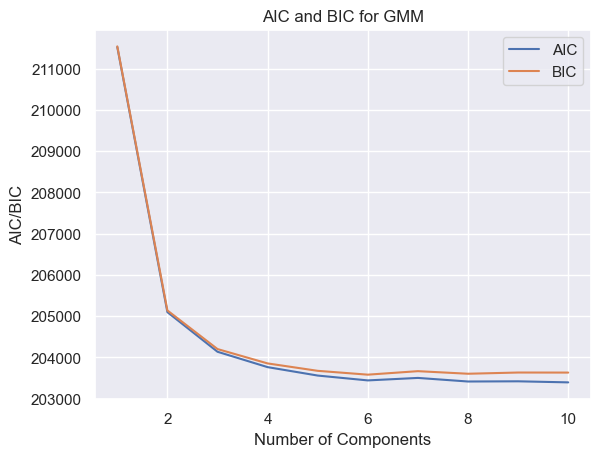

In [15]:
uif.GaussianMixtureBinning(df, ['Age_CAN'], RANDOM_STATE)

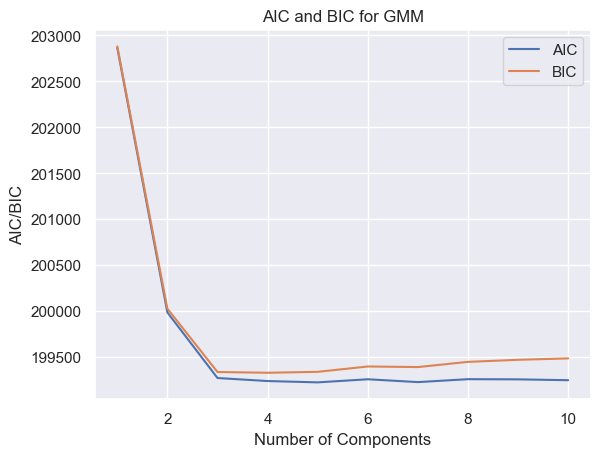

In [16]:
uif.GaussianMixtureBinning(df, ['Age_DON'], RANDOM_STATE)

In [17]:
df[features].describe().T

,count,mean,std,min,25%,50%,75%,max
Age_CAN,26600.0,53.414361,12.897743,18.0,46.0,56.0,63.0,79.0
Age_DON,26600.0,32.144023,10.959943,8.0,23.0,31.0,40.0,72.0


In [18]:
# use quartile bin
df['Age_CAT_CAN'] = pd.qcut(df['Age_CAN'], q=4, labels=['Age (Min-46)', 'Age(47-56)', 'Age(57-63)', 'Age(65-Max)'])
df['Age_CAT_DON'] = pd.qcut(df['Age_DON'], q=4, labels=['Age (Min-23)', 'Age(24-31)', 'Age(32-40)', 'Age(41-Max)'])

# category datatype
df['Age_CAT_CAN'] = df['Age_CAT_CAN'].astype('category')
df['Age_CAT_DON'] = df['Age_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['Age_CAT_CAN', 'Age_CAT_DON'])
df_don = uf.insertIntoDataFrame(df_don, ['Age_CAT_DON'])
df_can = uf.insertIntoDataFrame(df_can, ['Age_CAT_CAN'])

# add to list
removeCols = features

In [19]:
uf.categoryContingencySurvival(df, 'Age_CAT_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
Age (Min-46),3385.0,3327.0,6712.0,50.432062,49.567938
Age(47-56),3212.0,3409.0,6621.0,48.512309,51.487691
Age(57-63),3361.0,3428.0,6789.0,49.506555,50.493445
Age(65-Max),3278.0,3200.0,6478.0,50.602038,49.397962
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


In [20]:
uf.categoryContingencySurvival(df, 'Age_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
Age (Min-23),3110.0,3879.0,6989.0,44.498498,55.501502
Age(24-31),3538.0,3382.0,6920.0,51.127168,48.872832
Age(32-40),3444.0,2918.0,6362.0,54.133920,45.866080
Age(41-Max),3144.0,3185.0,6329.0,49.676094,50.323906
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


##### [BMI](https://www.cdc.gov/bmi/adult-calculator/bmi-categories.html)
- The standard BMI ranges for adults are:
    - Underweight: BMI less than 18.5 kg/m²
    - Normal weight: BMI 18.5 to 24.9 kg/m²
    - Overweight: BMI 25 to 29.9 kg/m²
    - Obesity: BMI 30 kg/m² or greater
    - BMI = Weight (kg) / Height (m)²

In [21]:
def categorizeBMI(value):
    """
    Define the function for mapping
    """
    if value < 18.5:
        return "Under Weight"
    elif 18.5 <= value <= 24.9:
        return "Normal Weight"        
    elif 24.9 <= value <= 29.9:
        return "Over Weight"
    elif value >= 29.9:
        return "Obesity"
    else:
        return "Unknown"

##### HeightCm

In [22]:
features = uf.getFeatureList(df, 'HeightCm')

                count        mean       std    min    25%    50%    75%    max
HeightCm_CAN  26600.0  173.649444  10.02993  124.0  167.6  175.0  180.3  213.4
HeightCm_DON  26600.0  173.887699   9.57433  115.0  167.6  175.0  180.3  213.0

:::: NaN Count:
HeightCm_CAN    0
HeightCm_DON    0


In [23]:
# use quartile bin
df['HeightCm_CAT_CAN'] = pd.qcut(df['HeightCm_CAN'], q=4, labels=['HeightCm (Min-168)', 'HeightCm(169-175)', 'HeightCm(176-181)', 'HeightCm(182-Max)'])
df['HeightCm_CAT_DON'] = pd.qcut(df['HeightCm_DON'], q=4, labels=['HeightCm (Min-168)', 'HeightCm(169-175)', 'HeightCm(176-181)', 'HeightCm(182-Max)'])

# category datatype
df['HeightCm_CAT_CAN'] = df['HeightCm_CAT_CAN'].astype('category')
df['HeightCm_CAT_DON'] = df['HeightCm_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['HeightCm_CAT_CAN', 'HeightCm_CAT_DON'])
df_don = uf.insertIntoDataFrame(df_don, ['HeightCm_CAT_DON'])
df_can = uf.insertIntoDataFrame(df_can, ['HeightCm_CAT_CAN'])

# add to list
removeCols.extend(features)

In [24]:
uf.categoryContingencySurvival(df, 'HeightCm_CAT_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
HeightCm (Min-168),4141.0,4017.0,8158.0,50.759990,49.240010
HeightCm(169-175),2522.0,2696.0,5218.0,48.332695,51.667305
HeightCm(176-181),3462.0,3578.0,7040.0,49.176136,50.823864
HeightCm(182-Max),3111.0,3073.0,6184.0,50.307245,49.692755
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


In [25]:
uf.categoryContingencySurvival(df, 'HeightCm_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
HeightCm (Min-168),3312.0,3594.0,6906.0,47.958297,52.041703
HeightCm(169-175),3755.0,3577.0,7332.0,51.213857,48.786143
HeightCm(176-181),2949.0,3011.0,5960.0,49.479866,50.520134
HeightCm(182-Max),3220.0,3182.0,6402.0,50.296782,49.703218
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


##### WeightKg

In [26]:
features = uf.getFeatureList(df, 'WeightKg')

                count       mean        std   min   25%   50%   75%    max
WeightKg_CAN  26593.0  83.200113  18.073713  29.9  70.3  82.5  95.3  159.1
WeightKg_DON  26597.0  83.449795  19.517050  23.2  70.0  80.6  94.0  198.0

:::: NaN Count:
WeightKg_CAN    7
WeightKg_DON    3


In [27]:
# new features
df['WeightKg_CAT_CAN'] = pd.qcut(df['WeightKg_CAN'], q=4, labels=['WeightKg (Min-70)', 'WeightKg(71-83)', 'WeightKg(84-96)', 'WeightKg(97-Max)'])
df['WeightKg_CAT_DON'] = pd.qcut(df['WeightKg_DON'], q=4, labels=['WeightKg (Min-70)', 'WeightKg(70-81)', 'WeightKg(82-94)', 'WeightKg(95-Max)'])

# category datatype
df['WeightKg_CAT_CAN'] = df['WeightKg_CAT_CAN'].astype('category')
df['WeightKg_CAT_DON'] = df['WeightKg_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['WeightKg_CAT_CAN', 'WeightKg_CAT_DON'])
df_don = uf.insertIntoDataFrame(df_don, ['WeightKg_CAT_DON'])
df_can = uf.insertIntoDataFrame(df_can, ['WeightKg_CAT_CAN'])

# add to list
removeCols.extend(features)

In [28]:
uf.categoryContingencySurvival(df, 'WeightKg_CAT_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
WeightKg (Min-70),3218.0,3512.0,6730.0,47.815750,52.184250
WeightKg(71-83),3222.0,3363.0,6585.0,48.929385,51.070615
WeightKg(84-96),3293.0,3384.0,6677.0,49.318556,50.681444
WeightKg(97-Max),3500.0,3101.0,6601.0,53.022269,46.977731
Column Total,13233.0,13360.0,26593.0,49.761215,50.238785


In [29]:
uf.categoryContingencySurvival(df, 'WeightKg_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
WeightKg (Min-70),3304.0,3699.0,7003.0,47.179780,52.820220
WeightKg(70-81),3111.0,3188.0,6299.0,49.388792,50.611208
WeightKg(82-94),3351.0,3334.0,6685.0,50.127150,49.872850
WeightKg(95-Max),3469.0,3141.0,6610.0,52.481089,47.518911
Column Total,13235.0,13362.0,26597.0,49.761251,50.238749


##### BMI

In [30]:
features = uf.getFeatureList(df, 'BMI_')

           count       mean       std        min        25%        50%        75%        max
BMI_CAN  26593.0  27.451597  4.862757  14.005023  23.872358  27.218198  30.963376  48.683517
BMI_DON  26597.0  27.581674  6.058856  13.128277  23.374726  26.528510  30.642536  74.321284

:::: NaN Count:
BMI_CAN    7
BMI_DON    3


In [31]:
# create New feature
df['BMI_CAT_CAN'] = df['BMI_CAN'].apply(categorizeBMI)
df['BMI_CAT_DON'] = df['BMI_DON'].apply(categorizeBMI)

# category datatype
df['BMI_CAT_CAN'] = df['BMI_CAT_CAN'].astype('category')
df['BMI_CAT_DON'] = df['BMI_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['BMI_CAT_CAN', 'BMI_CAT_DON'])
df_don = uf.insertIntoDataFrame(df_don, ['BMI_CAT_DON'])
df_can = uf.insertIntoDataFrame(df_can, ['BMI_CAT_CAN'])

# add to list
removeCols.extend(features)

In [32]:
uf.categoryContingencySurvival(df, 'BMI_CAT_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
Normal Weight,3803.0,4268.0,8071.0,47.119316,52.880684
Obesity,4409.0,3922.0,8331.0,52.922818,47.077182
Over Weight,4756.0,4866.0,9622.0,49.428393,50.571607
Under Weight,265.0,304.0,569.0,46.572935,53.427065
Unknown,3.0,4.0,7.0,42.857143,57.142857
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


In [33]:
uf.categoryContingencySurvival(df, 'BMI_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
Normal Weight,4526.0,4853.0,9379.0,48.256744,51.743256
Obesity,3946.0,3620.0,7566.0,52.154375,47.845625
Over Weight,4527.0,4634.0,9161.0,49.416003,50.583997
Under Weight,236.0,255.0,491.0,48.065173,51.934827
Unknown,1.0,2.0,3.0,33.333333,66.666667
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


##### [BloodPH](https://www.ncbi.nlm.nih.gov/books/NBK507807/)
- The normal blood pH range is indeed between 7.35 and 7.45. This slightly alkaline range is crucial for the proper functioning of enzymes and other biochemical reactions in the body.
    - A blood pH below 7.35 is considered acidic, and it can lead to a condition called acidosis. Acidosis can disrupt cellular functions and impair organ systems, particularly the cardiovascular and respiratory systems.
    - A blood pH above 7.45 is considered alkaline, and it can lead to a condition called alkalosis. Alkalosis can cause symptoms such as muscle twitching, hand tremors, and confusion.

In [34]:
def categorizePH(value):
    """
    Define the function for mapping
    """
    if value < 7.35:
        return "Acidic"
    elif value > 7.45:
        return "Alkaline"        
    elif 7.35 <= value <= 7.45:
        return "Normal"
    else:
        return "Unknown"

In [35]:
features = uf.getFeatureList(df, 'BloodPH')

               count      mean       std  min   25%   50%   75%   max
BloodPH_DON  26537.0  7.416184  0.071712  5.0  7.38  7.42  7.46  7.93

:::: NaN Count:
BloodPH_DON    63


In [36]:
# create New feature
df['BloodPH_CAT_DON'] = df['BloodPH_DON'].apply(categorizePH)

# category datatype
df['BloodPH_CAT_DON'] = df['BloodPH_CAT_DON'].astype('category')

# update DataFrame
df_nominal = uf.insertIntoDataFrame(df_nominal, ['BloodPH_CAT_DON'])
df_don = uf.insertIntoDataFrame(df_don, ['BloodPH_CAT_DON'])

# add to list
removeCols.extend(features)

In [37]:
uf.categoryContingencySurvival(df, 'BloodPH_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
Acidic,1578.0,1736.0,3314.0,47.616174,52.383826
Alkaline,3720.0,3556.0,7276.0,51.126993,48.873007
Normal,7894.0,8053.0,15947.0,49.501474,50.498526
Unknown,44.0,19.0,63.0,69.841270,30.158730
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


##### [BloodUreaNitrogenLevel](https://redcliffelabs.com/myhealth/lab-test/urea-normal-range-causes-procedure-and-treatment/)
- Blood Urea Nitrogen (BUN) is a common blood test that measures the amount of urea nitrogen in the blood, which is a waste product formed from the breakdown of proteins.
    - Source report a range of 8 to 24 mg/dL for adult men and 6 to 21 mg/dL for adult women. 

In [38]:
def categorizeBUN(value, gender):
    """
    Define the function for mapping Blood Urea Nitrogen levels based on value and gender.
    """
    if (0.8 <= value <= 24 and gender == 'M') or (6 <= value <= 21 and gender == 'F'):
        return 'Normal'
    elif (value < 0.8 and gender == 'M') or (value < 6 and gender == 'F'):
        return "Low"
    elif (value > 24 and gender == 'M') or (value > 21 and gender == 'F'):
        return "High"
    else:
        return "Unknown"

In [39]:
features = uf.getFeatureList(df, 'BloodUreaNitrogenLevel_DON')

                              count       mean        std  min   25%   50%   75%    max
BloodUreaNitrogenLevel_DON  26560.0  24.173811  19.996607  0.5  12.0  18.0  29.0  250.0

:::: NaN Count:
BloodUreaNitrogenLevel_DON    40


In [40]:
# create new feature
df['BloodUreaNitrogenLevel_CAT_DON'] = df.apply(lambda row: categorizeBUN(row['BloodUreaNitrogenLevel_DON'], row['Gender_DON']), axis=1)

# category datatype
df['BloodUreaNitrogenLevel_CAT_DON'] = df['BloodUreaNitrogenLevel_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['BloodUreaNitrogenLevel_CAT_DON'])
df_don = uf.insertIntoDataFrame(df_don, ['BloodUreaNitrogenLevel_CAT_DON'])

# add to list
removeCols.extend(features)

In [41]:
uf.categoryContingencySurvival(df, 'BloodUreaNitrogenLevel_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
High,5336.0,3737.0,9073.0,58.811859,41.188141
Low,113.0,217.0,330.0,34.242424,65.757576
Normal,7761.0,9396.0,17157.0,45.235181,54.764819
Unknown,26.0,14.0,40.0,65.000000,35.000000
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


##### [Creatinine](https://johnshopkinshealthcare.staywellsolutionsonline.com/BreatheEasy/167,creatinine_serum)
- Creatinine is a waste product that forms when creatine, a substance found in your muscles, breaks down. It's usually filtered out of the blood by the kidneys and excreted in urine. Measuring creatinine levels in the blood can help assess kidney function.
    - Normal
        - 0.7 to 1.3 mg/dL for adult males
        - 0.5 to 1.1 mg/dL for adult females
- High creatinine levels can indicate kidney dysfunction, dehydration, or other conditions affecting the kidneys. If you have concerns about your creatinine levels, it's best to consult with a healthcare professional for proper evaluation and guidance.

In [42]:
def categorizeCR(value, gender):
    """
    Define the function for mapping creatinine levels based on value and gender.
    """
    if (0.7 <= value <= 1.3 and gender == 'M') or (0.5 <= value <= 1.1 and gender == 'F'):
        return 'Normal'
    elif (value < 0.7 and gender == 'M') or (value < 0.5 and gender == 'F'):
        return "Low"
    elif (value > 1.3 and gender == 'M') or (value > 1.1 and gender == 'F'):
        return "Elevated"
    else:
        return "Unknown"

In [43]:
features = uf.getFeatureList(df, 'Creatinine')

                              count      mean       std   min   25%  50%   75%   max
CreatinineRegistration_CAN  26579.0  1.362137  0.953078  0.08  0.94  1.2  1.50  24.0
CreatinineTransplant_CAN    26579.0  1.371054  0.997589  0.06  0.94  1.2  1.50  37.0
Creatinine_DON              26560.0  1.503744  1.556497  0.04  0.76  1.0  1.49  23.0

:::: NaN Count:
CreatinineRegistration_CAN    21
CreatinineTransplant_CAN      21
Creatinine_DON                40


In [44]:
df.groupby('Gender_DON', observed=False)['Creatinine_DON'].describe()

,count,mean,std,min,25%,50%,75%,max
Gender_DON,,,,,,,,
F,7837.0,1.296950,1.341491,0.04,0.62,0.81,1.30,15.0
M,18723.0,1.590303,1.630402,0.05,0.80,1.08,1.52,23.0


In [45]:
# create new feature
df['Creatinine_Mean_CAN'] = df[['CreatinineRegistration_CAN','CreatinineTransplant_CAN']].mean(axis=1)

# update PanelReactiveAntibody_CPRA_CAN with non-NaN values from CreatinineRegistration_CAN and CreatinineTransplant_CAN
df['Creatinine_Mean_CAN'] = df['Creatinine_Mean_CAN'].fillna(df['CreatinineRegistration_CAN'].combine_first(df['CreatinineTransplant_CAN']))

In [46]:
# create new feature
df['Creatinine_CAT_CAN'] = df.apply(lambda row: categorizeCR(row['Creatinine_Mean_CAN'], row['Gender_CAN']), axis=1)
df['Creatinine_CAT_DON'] = df.apply(lambda row: categorizeCR(row['Creatinine_DON'], row['Gender_DON']), axis=1)
                                    
# category datatype
df['Creatinine_CAT_CAN'] = df['Creatinine_CAT_CAN'].astype('category')

# update dataframe
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['Creatinine_CAT_CAN', 'Creatinine_CAT_DON'])
df_can = uf.insertIntoDataFrame(df_can, ['Creatinine_CAT_CAN'])
df_don = uf.insertIntoDataFrame(df_don, ['Creatinine_CAT_DON'])

# add to list
removeCols.extend(features)
removeCols.extend(['Creatinine_Mean_CAN'])                                  

In [47]:
uf.categoryContingencySurvival(df, 'Creatinine_CAT_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
Elevated,5935.0,5464.0,11399.0,52.065971,47.934029
Low,196.0,170.0,366.0,53.551913,46.448087
Normal,7084.0,7730.0,14814.0,47.819630,52.180370
Unknown,21.0,0.0,21.0,100.000000,0.000000
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


In [48]:
uf.categoryContingencySurvival(df, 'Creatinine_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
Elevated,4480.0,3918.0,8398.0,53.346035,46.653965
Low,1395.0,1240.0,2635.0,52.941176,47.058824
Normal,7335.0,8192.0,15527.0,47.240291,52.759709
Unknown,26.0,14.0,40.0,65.000000,35.000000
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


##### DistanceFromDonorHospitaltoTXCenter

In [49]:
features = uf.getFeatureList(df, 'DistanceFromDonorHospitaltoTXCenter')

                                       count        mean         std  min   25%    50%    75%     max
DistanceFromDonorHospitaltoTXCenter  26600.0  199.702857  220.905299  0.0  20.0  125.0  319.0  2215.0

:::: NaN Count:
DistanceFromDonorHospitaltoTXCenter    0


In [50]:
# use quartile bin
df['DistanceFromDonorHospitaltoTXCenter_CAT'] = pd.qcut(df['DistanceFromDonorHospitaltoTXCenter'], q=4, labels=['Distance(Min-37)', 'Distance(38-167)', 'Distance(167-354)', 'Distance(354-Max)'])

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['DistanceFromDonorHospitaltoTXCenter_CAT'])
df_both = uf.insertIntoDataFrame(df_both, ['DistanceFromDonorHospitaltoTXCenter_CAT'])

# add to list
removeCols.extend(features)

In [51]:
uf.categoryContingencySurvival(df, 'DistanceFromDonorHospitaltoTXCenter_CAT')

Survival,Dead,Living,Row Total,Dead %,Living %
Distance(Min-37),2383.0,4280.0,6663.0,35.764671,64.235329
Distance(38-167),2913.0,3739.0,6652.0,43.791341,56.208659
Distance(167-354),3877.0,2767.0,6644.0,58.353402,41.646598
Distance(354-Max),4063.0,2578.0,6641.0,61.180545,38.819455
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


##### [Hematocrit_DON](https://www.mountsinai.org/health-library/tests/hematocrit)
- Hematocrit is a blood test that measures how much of a person's blood is made up of red blood cells as opposed to plasma.
    - Normal results vary, but in general they are:
        - Male: 40.7% to 50.3%
        - Female: 36.1% to 44.3% 

In [52]:
def categorizeH(value, gender):
    """
    Define the function for mapping Hematocrit levels based on value and gender.
    """
    if (40.7 <= value <= 50.3 and gender == 'M') or (36.1 <= value <= 44.3 and gender == 'F'):
        return 'Normal'
    elif (value < 40.7 and gender == 'M') or (value < 36.1 and gender == 'F'):
        return "Low"
    elif (value > 50.3 and gender == 'M') or (value > 44.3 and gender == 'F'):
        return "Elevated"
    else:
        return "Unknown"

In [53]:
features = uf.getFeatureList(df, 'Hematocrit')

                  count       mean       std  min   25%   50%   75%   max
Hematocrit_DON  26560.0  28.404058  5.006004  2.3  25.0  27.9  31.3  75.0

:::: NaN Count:
Hematocrit_DON    40


In [54]:
# create new feature
df['Hematocrit_CAT_DON'] = df.apply(lambda row: categorizeH(row['Hematocrit_DON'], row['Gender_DON']), axis=1)
                                    
# category datatype
df['Hematocrit_CAT_DON'] = df['Hematocrit_CAT_DON'].astype('category')

# update dataframe
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['Hematocrit_CAT_DON'])
df_don = uf.insertIntoDataFrame(df_don, ['Hematocrit_CAT_DON'])

# add to list
removeCols.extend(features)

In [55]:
uf.categoryContingencySurvival(df, 'Hematocrit_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
Elevated,13.0,21.0,34.0,38.235294,61.764706
Low,12923.0,12925.0,25848.0,49.996131,50.003869
Normal,274.0,404.0,678.0,40.412979,59.587021
Unknown,26.0,14.0,40.0,65.000000,35.000000
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


##### Hemodynamics
- [CO (Cardiac Output)](https://www.ncbi.nlm.nih.gov/books/NBK470455/#:~:text=Cardiac%20output%20in%20humans%20is,to%20100%20times%20each%20minute.):
    - Definition: Similar to the registration phase, it measures the heart's output during the transplant phase.
    - Importance: Critical for ensuring adequate perfusion during surgery.
    - Cardiac output in humans is generally 5-6 L/min
- [PA_DIA (Pulmonary Artery Diastolic Pressure)](https://www.ncbi.nlm.nih.gov/books/NBK209987/):
    - Definition: Monitored to assess right heart function and pulmonary circulation during transplant.
- [PA_MN (Pulmonary Artery Mean Pressure)](https://www.ncbi.nlm.nih.gov/books/NBK209987/):
    - Definition: Helps in evaluating pulmonary hypertension and right ventricular function.
    - Severe pulmonary hypertension artery pressure of 40 mm Hg or greater
    - Moderate pulmonary hypertension artery pressure between 25 and 39 mm Hg
    - Normal pulmonary artery pressure between 11 and 25 mm Hg
- [PCW (Pulmonary Capillary Wedge Pressure)](https://pubmed.ncbi.nlm.nih.gov/24268673/):
    - Definition: Used to monitor left ventricular function and fluid status during transplant.
- [SYS (Systemic Arterial Pressure)](https://www.ncbi.nlm.nih.gov/books/NBK538509/):
    - Definition: Monitored to ensure stable blood pressure and perfusion during transplant.

In [56]:
def categorizeCO(value):
    """
    Define the function for mapping Hemodynamics levels.
    """
    if value < 5:
        return "Low"
    elif value > 6:
        return "High"    
    if 5 <= value <= 6:
        return "Normal"
    else:
        return "Unknown"

def categorizePA(value):
    """
    Define the function for mapping Hemodynamics levels.
    """
    if value < 11:
        return 'Low'
    elif 11 <= value <= 25:
        return "Normal"
    elif 25 <= value <= 40:
        return "High"
    elif value >= 40:
        return "Extreme"
    else:
        return "Unknown"

In [57]:
features = uf.getFeatureList(df, 'Hemodynamics')

                                       count       mean        std   min    25%    50%    75%    max
HemodynamicsRegistration_CO_CAN      26068.0   4.272608   1.356561  0.39   3.33   4.11   5.00   15.0
HemodynamicsRegistration_PA_DIA_CAN  26205.0  20.459653   8.682346  0.00  14.00  20.00  26.00   91.0
HemodynamicsRegistration_PA_MN_CAN   26170.0  28.527231  10.195191  0.00  21.00  28.00  36.00   96.0
HemodynamicsRegistration_PCW_CAN     25707.0  19.124673   8.824426  0.00  12.00  19.00  25.00   50.0
HemodynamicsRegistration_SYS_CAN     26212.0  41.869182  14.216455  0.00  31.00  41.00  51.00  130.0
HemodynamicsTransplant_CO_CAN        26068.0   4.521948   1.456154  0.20   3.50   4.38   5.32   15.0
HemodynamicsTransplant_PA_DIA_CAN    26205.0  19.168869   8.484892  0.00  13.00  18.00  25.00  110.0
HemodynamicsTransplant_PA_MN_CAN     26170.0  27.031698   9.918232  0.00  20.00  26.00  34.00  110.0
HemodynamicsTransplant_PCW_CAN       25707.0  17.892101   8.714694  0.00  11.00  17.00  24.

In [58]:
# mean (Registration & Transplant)
df['Hemodynamics_Mean_CO_CAN'] = df[['HemodynamicsRegistration_CO_CAN', 'HemodynamicsTransplant_CO_CAN']].mean(axis=1)
df['Hemodynamics_Mean_PA_DIA_CAN'] = df[['HemodynamicsRegistration_PA_DIA_CAN', 'HemodynamicsTransplant_PA_DIA_CAN']].mean(axis=1)
df['Hemodynamics_Mean_PA_MN_CAN'] = df[['HemodynamicsRegistration_PA_MN_CAN', 'HemodynamicsTransplant_PA_MN_CAN']].mean(axis=1)
df['Hemodynamics_Mean_PCW_CAN'] = df[['HemodynamicsRegistration_PCW_CAN', 'HemodynamicsTransplant_PCW_CAN']].mean(axis=1)
df['Hemodynamics_Mean_SYS_CAN'] = df[['HemodynamicsRegistration_SYS_CAN', 'HemodynamicsTransplant_SYS_CAN']].mean(axis=1)

# update Hemodynamics_Mean with non-NaN values from Registration and Transplant
df['Hemodynamics_Mean_CO_CAN'] = df['Hemodynamics_Mean_CO_CAN'].fillna(df['HemodynamicsRegistration_CO_CAN'].combine_first(df['HemodynamicsTransplant_CO_CAN']))
df['Hemodynamics_Mean_PA_DIA_CAN'] = df['Hemodynamics_Mean_PA_DIA_CAN'].fillna(df['HemodynamicsRegistration_PA_DIA_CAN'].combine_first(df['HemodynamicsTransplant_PA_DIA_CAN']))
df['Hemodynamics_Mean_PA_MN_CAN'] = df['Hemodynamics_Mean_PA_MN_CAN'].fillna(df['HemodynamicsRegistration_PA_MN_CAN'].combine_first(df['HemodynamicsTransplant_PA_MN_CAN']))
df['Hemodynamics_Mean_PCW_CAN'] = df['Hemodynamics_Mean_PCW_CAN'].fillna(df['HemodynamicsRegistration_PCW_CAN'].combine_first(df['HemodynamicsTransplant_PCW_CAN']))
df['Hemodynamics_Mean_SYS_CAN'] = df['Hemodynamics_Mean_SYS_CAN'].fillna(df['HemodynamicsRegistration_SYS_CAN'].combine_first(df['HemodynamicsTransplant_SYS_CAN']))

In [59]:
featuresMean = uf.getFeatureList(df, 'Hemodynamics_Mean')

                                count       mean        std   min     25%   50%   75%    max
Hemodynamics_Mean_CO_CAN      26068.0   4.397278   1.238842  0.98   3.535   4.3   5.1   15.0
Hemodynamics_Mean_PA_DIA_CAN  26205.0  19.814261   7.532167  0.00  14.500  19.5  25.0   82.0
Hemodynamics_Mean_PA_MN_CAN   26170.0  27.779465   8.936825  0.00  21.000  27.5  34.0   84.0
Hemodynamics_Mean_PCW_CAN     25707.0  18.508387   7.847699  0.00  13.000  18.0  24.0   50.0
Hemodynamics_Mean_SYS_CAN     26212.0  40.804322  12.501636  1.00  32.000  40.0  49.0  109.0

:::: NaN Count:
Hemodynamics_Mean_CO_CAN        532
Hemodynamics_Mean_PA_DIA_CAN    395
Hemodynamics_Mean_PA_MN_CAN     430
Hemodynamics_Mean_PCW_CAN       893
Hemodynamics_Mean_SYS_CAN       388


##### Parameters related to pulmonary and systemic pressures (PA_DIA, PA_MN, PCW, SYS) are strongly positively correlated. This means that when one of these pressures increases, the others will also increase; therefore, use PA_MN ONLY.

In [60]:
df[featuresMean].corr()

,Hemodynamics_Mean_CO_CAN,Hemodynamics_Mean_PA_DIA_CAN,Hemodynamics_Mean_PA_MN_CAN,Hemodynamics_Mean_PCW_CAN,Hemodynamics_Mean_SYS_CAN
Hemodynamics_Mean_CO_CAN,1.000000,-0.198448,-0.167445,-0.203252,-0.133975
Hemodynamics_Mean_PA_DIA_CAN,-0.198448,1.000000,0.905552,0.820405,0.800022
Hemodynamics_Mean_PA_MN_CAN,-0.167445,0.905552,1.000000,0.827374,0.920766
Hemodynamics_Mean_PCW_CAN,-0.203252,0.820405,0.827374,1.000000,0.752750
Hemodynamics_Mean_SYS_CAN,-0.133975,0.800022,0.920766,0.752750,1.000000


In [61]:
# create New feature
df['Hemodynamics_Mean_PA_MN_CAT_CAN'] = df['Hemodynamics_Mean_PA_MN_CAN'].apply(categorizePA)
df['Hemodynamics_Mean_CO_CAT_CAN'] = df['Hemodynamics_Mean_CO_CAN'].apply(categorizeCO)

# category datatype
df['Hemodynamics_Mean_PA_MN_CAT_CAN'] = df['Hemodynamics_Mean_PA_MN_CAT_CAN'].astype('category')
df['Hemodynamics_Mean_CO_CAT_CAN'] = df['Hemodynamics_Mean_CO_CAT_CAN'].astype('category')

# update dataframe
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['Hemodynamics_Mean_PA_MN_CAT_CAN', 'Hemodynamics_Mean_CO_CAT_CAN'])
df_can = uf.insertIntoDataFrame(df_can, ['Hemodynamics_Mean_PA_MN_CAT_CAN', 'Hemodynamics_Mean_CO_CAT_CAN'])

# combine
features.extend(featuresMean)
# add to list
removeCols.extend(features)

In [62]:
uf.categoryContingencySurvival(df, 'Hemodynamics_Mean_PA_MN_CAT_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
Extreme,1116.0,998.0,2114.0,52.790918,47.209082
High,6443.0,6833.0,13276.0,48.531184,51.468816
Low,171.0,162.0,333.0,51.351351,48.648649
Normal,5270.0,5177.0,10447.0,50.445104,49.554896
Unknown,236.0,194.0,430.0,54.883721,45.116279
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


In [63]:
uf.categoryContingencySurvival(df, 'Hemodynamics_Mean_CO_CAT_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
High,1231.0,1229.0,2460.0,50.040650,49.959350
Low,9397.0,9352.0,18749.0,50.120006,49.879994
Normal,2307.0,2552.0,4859.0,47.478905,52.521095
Unknown,301.0,231.0,532.0,56.578947,43.421053
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


##### [IschemicTimeHour](https://www.jhltonline.org/article/S1053-2498(23)01819-3/fulltext)
-  The maximum time it can be without blood supply before significant damage occurs, is around 4 hours when preserved in cold storage for transplantation; exceeding this timeframe significantly increases the risk of complications and poor outcomes after transplant. 

In [64]:
def categoryISC(value):
    if value <= 2.6:
        return 'Low'
    elif 2.6 <= value <= 4:
        return 'Normal'
    elif value > 4:
        return 'High'
    else:
        return 'Unknown'

In [65]:
features = uf.getFeatureList(df, 'IschemicTimeHour_DON')

                        count      mean       std  min  25%  50%  75%   max
IschemicTimeHour_DON  26441.0  3.229935  1.067772  0.3  2.5  3.2  3.9  12.0

:::: NaN Count:
IschemicTimeHour_DON    159


In [66]:
# create New feature
df['IschemicTimeHour_CAT'] = df['IschemicTimeHour_DON'].apply(categoryISC)
# category datatype
df['IschemicTimeHour_CAT'] = df['IschemicTimeHour_CAT'].astype('category')

# update dataframe
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['IschemicTimeHour_CAT'])
df_both = uf.insertIntoDataFrame(df_both, ['IschemicTimeHour_CAT'])

# add to list
removeCols.extend(features)

In [67]:
uf.categoryContingencySurvival(df, 'IschemicTimeHour_CAT')

Survival,Dead,Living,Row Total,Dead %,Living %
High,2804.0,2094.0,4898.0,57.247856,42.752144
Low,3104.0,4635.0,7739.0,40.108541,59.891459
Normal,7228.0,6576.0,13804.0,52.361634,47.638366
Unknown,100.0,59.0,159.0,62.893082,37.106918
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


##### [LV_EjectionFractionPercent](https://my.clevelandclinic.org/health/articles/16950-ejection-fraction)
- Ejection fraction measures your heart’s ability to pump oxygen-rich blood out to your body. In a healthy heart, the fraction is a higher number. A low number means that your heart has difficulty keeping up with your body’s needs.
    - Male:
        - Nomal: 52% to 72%
        - Mildly Abnormal: 41% to 51%
        - Moderately Abnormal: 30% to 40%
        - Severely Abnormal: Below 30% 
    - Female:
        - Nomal: 54% to 74%
        - Mildly Abnormal: 41% to 53%
        - Moderately Abnormal: 30% to 40%
        - Severely Abnormal: Below 30% 

In [68]:
def categorizeLV(value, gender):
    """
    Define the function for mapping LV Ejection Fraction Percent based on value and gender.
    """
    if (52 <= value <= 72 and gender == 'M') or (54 <= value <= 74 and gender == 'F'):
        return 'Normal'
    elif (41 <= value <= 52 and gender == 'M') or (41 <= value <= 54 and gender == 'F'):
        return "Mildly Abnormal"
    elif (30 <= value <= 41) and gender in ['M', 'F']:
        return "Moderately Abnormal"
    elif (value < 30) and gender in ['M', 'F']:
        return "Severely Abnormal"
    elif (value > 72 and gender == 'M') or (value > 74 and gender == 'F'):
        return 'Below Normal'
    else:
        return "Unknown"

In [69]:
features = uf.getFeatureList(df, 'LV_EjectionFractionPercent_DON')

                                  count       mean      std   min   25%   50%   75%   max
LV_EjectionFractionPercent_DON  26573.0  61.619139  6.64542  10.0  56.0  60.0  65.0  99.0

:::: NaN Count:
LV_EjectionFractionPercent_DON    27


In [70]:
# create new feature
df['LV_EjectionFractionPercent_CAT_DON'] = df.apply(lambda row: categorizeLV(row['LV_EjectionFractionPercent_DON'], row['Gender_DON']), axis=1)

# category datatype
df['LV_EjectionFractionPercent_CAT_DON'] = df['LV_EjectionFractionPercent_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['LV_EjectionFractionPercent_CAT_DON'])
df_don = uf.insertIntoDataFrame(df_don, ['LV_EjectionFractionPercent_CAT_DON'])

# add to list
removeCols.extend(features)

In [71]:
df.groupby('Gender_DON', observed=False)['LV_EjectionFractionPercent_CAT_DON'].describe()

,count,unique,top,freq
Gender_DON,,,,
F,7849,6,Normal,7040
M,18751,6,Normal,16701


In [72]:
uf.categoryContingencySurvival(df, 'LV_EjectionFractionPercent_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
Below Normal,630.0,689.0,1319.0,47.763457,52.236543
Mildly Abnormal,647.0,750.0,1397.0,46.313529,53.686471
Moderately Abnormal,55.0,48.0,103.0,53.398058,46.601942
Normal,11883.0,11858.0,23741.0,50.052652,49.947348
Severely Abnormal,11.0,2.0,13.0,84.615385,15.384615
Unknown,10.0,17.0,27.0,37.037037,62.962963
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


##### Level_SGOT
- `SGOT`, also known as aspartate aminotransferase `(AST)`, is an enzyme primarily found in the liver, heart, kidneys, and muscles. It plays a crucial role in amino acid metabolism by catalyzing the transfer of an amino group from aspartate to α-ketoglutarate, producing oxaloacetate and glutamate.
    - Conservative normal range of 8 to 45 units/L for healthy individuals. 
- Alanine aminotransferase `(ALT)`, also known as serum glutamic-pyruvic transaminase `(SGPT)`, is an enzyme primarily found in the liver. It plays a crucial role in amino acid metabolism by catalyzing the conversion of alanine and α-ketoglutarate into pyruvate and glutamate. ALT is commonly measured in blood tests to evaluate liver function and detect liver damage.
    - The typical normal range for ALT is approximately 7 to 56 units per liter (U/L) of serum. However, ranges may vary slightly between laboratories. 

In [73]:
def categoryAST(value):
    if value <= 8:
        return 'Low'
    elif 8 <= value <= 45:
        return 'Normal'
    elif value > 45:
        return 'High'
    else:
        return 'Unknown'


def categoryALT(value):
    if value <= 7:
        return 'Low'
    elif 7 <= value <= 56:
        return 'Normal'
    elif value > 56:
        return 'High'
    else:
        return 'Unknown'

In [74]:
features = uf.getFeatureList(df, 'Level_SGOT')

                      count        mean         std  min   25%   50%   75%      max
Level_SGOT_ALT_DON  26556.0  114.537393  410.851176  3.0  23.0  41.0  83.0  44117.0
Level_SGOT_AST_DON  26556.0  101.949910  302.800755  0.3  26.0  44.0  87.0  10254.0

:::: NaN Count:
Level_SGOT_ALT_DON    44
Level_SGOT_AST_DON    44


In [75]:
df[features].corr()

,Level_SGOT_ALT_DON,Level_SGOT_AST_DON
Level_SGOT_ALT_DON,1.000000,0.551933
Level_SGOT_AST_DON,0.551933,1.000000


In [76]:
# create New feature
df['SOGT_ALT_CAT_DON'] = df['Level_SGOT_ALT_DON'].apply(categoryALT)
df['SOGT_AST_CAT_DON'] = df['Level_SGOT_AST_DON'].apply(categoryAST)
# category datatype
df['SOGT_ALT_CAT_DON'] = df['SOGT_ALT_CAT_DON'].astype('category')
df['SOGT_AST_CAT_DON'] = df['SOGT_AST_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['SOGT_AST_CAT_DON', 'SOGT_ALT_CAT_DON'])
df_don = uf.insertIntoDataFrame(df_don, ['SOGT_AST_CAT_DON', 'SOGT_ALT_CAT_DON'])

# add to list
removeCols.extend(features)

In [77]:
uf.categoryContingencySurvival(df, 'SOGT_ALT_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
High,5110.0,4676.0,9786.0,52.217454,47.782546
Low,88.0,102.0,190.0,46.315789,53.684211
Normal,8011.0,8569.0,16580.0,48.317250,51.682750
Unknown,27.0,17.0,44.0,61.363636,38.636364
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


In [78]:
uf.categoryContingencySurvival(df, 'SOGT_AST_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
High,6452.0,6559.0,13011.0,49.588809,50.411191
Low,96.0,105.0,201.0,47.761194,52.238806
Normal,6661.0,6683.0,13344.0,49.917566,50.082434
Unknown,27.0,17.0,44.0,61.363636,38.636364
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


##### [OrganRecovery_PCO2_DON](https://www.ncbi.nlm.nih.gov/books/NBK551648/)
- A blood gas test is performed to measure the amount of C02 in the blood. When the lung’s ability to exchange oxygen and C02 becomes impaired, the PC02 level may become increased. The candidate’s current PC02 and change in PC02 are both considered in the lung allocation score calculation to reflect worsening PC02 values. PCO2 is used in the Lung Allocation Score.
- The normal range for the partial pressure of carbon dioxide (pCO2) in arterial blood is typically between 35 to 45 mmHg

In [79]:
def categoryPCO2(value):
    if value < 35:
        return 'Low'
    elif 35 <= value <= 45:
        return 'Normal'
    elif value > 45:
        return 'High'
    else:
        return 'Unknown'

In [80]:
features = uf.getFeatureList(df, 'OrganRecovery_PCO2_DON')

                          count       mean       std   min   25%   50%   75%    max
OrganRecovery_PCO2_DON  26531.0  38.640024  7.026554  10.1  34.0  38.0  42.1  116.3

:::: NaN Count:
OrganRecovery_PCO2_DON    69


In [81]:
# new feature
df['OrganRecovery_PCO2_CAT_DON'] = df.OrganRecovery_PCO2_DON.apply(categoryPCO2)

# category datatype
df['OrganRecovery_PCO2_CAT_DON'] = df['OrganRecovery_PCO2_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['OrganRecovery_PCO2_CAT_DON'])
df_don = uf.insertIntoDataFrame(df_don, ['OrganRecovery_PCO2_CAT_DON'])

# add to list
removeCols.extend(features)

In [82]:
uf.categoryContingencySurvival(df, 'OrganRecovery_PCO2_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
High,2018.0,1727.0,3745.0,53.885180,46.114820
Low,3364.0,4151.0,7515.0,44.763806,55.236194
Normal,7805.0,7466.0,15271.0,51.109947,48.890053
Unknown,49.0,20.0,69.0,71.014493,28.985507
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


##### Bilirubin
- Bilirubin levels can be an important factor in heart transplantation, particularly in the context of post-operative outcomes. Elevated bilirubin levels, or hyperbilirubinemia, can indicate liver dysfunction, which is a common complication following cardiac surgery, including heart transplantation.
    - Prognostic Marker: Hyperbilirubinemia is often used as a prognostic marker for adverse outcomes after cardiac surgery. Elevated bilirubin levels are associated with increased in-hospital mortality, prolonged ICU stays, and other complications.
    - Incidence and Risk Factors: The incidence of hyperbilirubinemia after cardiac surgery varies widely, with reports ranging from 8.6% to 40%. Risk factors include the type of surgery, duration of cardiopulmonary bypass, and pre-existing liver conditions.
    - Management: Managing elevated bilirubin levels involves addressing the underlying causes, such as improving liver perfusion and reducing hemolysis. Treatments like bilirubin adsorption and plasma exchange have been studied for their efficacy in reducing bilirubin levels and improving outcomes.
    - Impact on Transplant Outcomes: High bilirubin levels can complicate the post-operative course and affect the overall success of the heart transplant. Monitoring and managing bilirubin levels is crucial for improving patient outcomes. 

In [83]:
features = uf.getFeatureList(df, 'TotalBilirubin')

                                count      mean       std  min  25%  50%  75%   max
TerminalTotalBilirubin_DON    26557.0  1.044862  1.432232  0.0  0.5  0.7  1.1  45.4
TotalBilirubinTransplant_CAN  26521.0  0.986492  1.695361  0.1  0.5  0.7  1.1  80.0

:::: NaN Count:
TerminalTotalBilirubin_DON      43
TotalBilirubinTransplant_CAN    79


In [84]:
def catMapB(value):
    if value <= 1.2:
        return 'Normal'
    elif value > 1.2:
        return 'High'
    else:
        return 'Unknown'

In [85]:
# new features
df['Bilirubin_CAT_CAN'] = df['TotalBilirubinTransplant_CAN'].map(catMapB).fillna(df['TotalBilirubinTransplant_CAN'])
df['Bilirubin_CAT_DON'] = df['TerminalTotalBilirubin_DON'].map(catMapB).fillna(df['TerminalTotalBilirubin_DON'])

# category datatype
df['Bilirubin_CAT_CAN'] = df['Bilirubin_CAT_CAN'].astype('category')
df['Bilirubin_CAT_DON'] = df['Bilirubin_CAT_DON'].astype('category')

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['Bilirubin_CAT_CAN', 'Bilirubin_CAT_DON'])
df_can = uf.insertIntoDataFrame(df_can, ['Bilirubin_CAT_CAN'])
df_don = uf.insertIntoDataFrame(df_don, ['Bilirubin_CAT_DON'])

# add to list
removeCols.extend(features)

In [86]:
uf.categoryContingencySurvival(df, 'Bilirubin_CAT_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
High,2623.0,2382.0,5005.0,52.407592,47.592408
Normal,10558.0,10958.0,21516.0,49.070459,50.929541
Unknown,55.0,24.0,79.0,69.620253,30.379747
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


In [87]:
uf.categoryContingencySurvival(df, 'Bilirubin_CAT_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
High,2755.0,2905.0,5660.0,48.674912,51.325088
Normal,10454.0,10443.0,20897.0,50.026320,49.973680
Unknown,27.0,16.0,43.0,62.790698,37.209302
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


##### TotalDayWaitList_CAN

In [88]:
features = uf.getFeatureList(df, 'TotalDayWaitList')

                        count        mean         std  min   25%   50%    75%     max
TotalDayWaitList_CAN  26600.0  193.760977  311.323161  0.0  18.0  70.0  233.0  3835.0

:::: NaN Count:
TotalDayWaitList_CAN    0


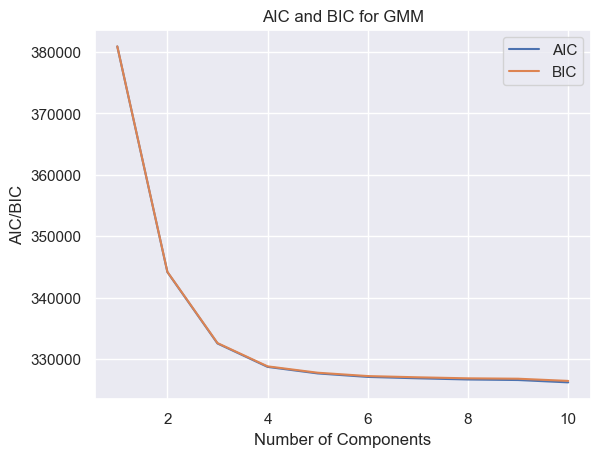

In [89]:
uif.GaussianMixtureBinning(df, features, RANDOM_STATE)

In [90]:
# new features
df['TotalDayWaitList_CAT_CAN'] = pd.qcut(df['TotalDayWaitList_CAN'], q=4, labels=['TotalDayWaitList (Min-18)', 'TotalDayWaitList (19-70)', 'TotalDayWaitList (71-233)', 'TotalDayWaitList (234-Max)'])

# category datatype
df['TotalDayWaitList_CAT_CAN'] = df['TotalDayWaitList_CAT_CAN'].astype('category')

# update DataFrame
df_ordinal = uf.insertIntoDataFrame(df_ordinal, ['TotalDayWaitList_CAT_CAN'])
df_can = uf.insertIntoDataFrame(df_can, ['TotalDayWaitList_CAT_CAN'])

# add to list
removeCols.extend(features)

In [91]:
uf.categoryContingencySurvival(df, 'TotalDayWaitList_CAT_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
TotalDayWaitList (Min-18),4265.0,2419.0,6684.0,63.809096,36.190904
TotalDayWaitList (19-70),3246.0,3408.0,6654.0,48.782687,51.217313
TotalDayWaitList (71-233),2722.0,3904.0,6626.0,41.080592,58.919408
TotalDayWaitList (234-Max),3003.0,3633.0,6636.0,45.253165,54.746835
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


In [92]:
# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.HouseKeeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 0 row(s) from df_label DataFrame.
Remove 20 row(s) from df_can DataFrame.
Remove 13 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 0 row(s) from df_ordinal DataFrame.
Remove 0 row(s) from df_nominal DataFrame.
Remove 33 row(s) from df_numeric DataFrame.
Remove 24 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['Age_CAN', 'Age_DON', 'BMI_CAN', 'BMI_DON', 'BloodPH_DON', 'BloodUreaNitrogenLevel_DON', 'CreatinineRegistration_CAN', 'CreatinineTransplant_CAN', 'Creatinine_DON', 'Creatinine_Mean_CAN', 'DistanceFromDonorHospitaltoTXCenter', 'HeightCm_CAN', 'HeightCm_DON', 'Hematocrit_DON', 'HemodynamicsRegistration_CO_CAN', 'HemodynamicsRegistration_PA_DIA_CAN', 'HemodynamicsRegistration_PA_MN_CAN', 'HemodynamicsRegistration_PCW_CAN', 'HemodynamicsRegistration_SYS_CAN', 'HemodynamicsTransplant_CO_CAN', 'Hem

### ENCODE

In [93]:
print(sorted(df_ordinal.column.to_list()))

['Age_CAT_CAN', 'Age_CAT_DON', 'BMI_CAT_CAN', 'BMI_CAT_DON', 'Bilirubin_CAT_CAN', 'Bilirubin_CAT_DON', 'BloodUreaNitrogenLevel_CAT_DON', 'CigaretteAbstinence_CAN', 'Creatinine_CAT_CAN', 'Creatinine_CAT_DON', 'DiabetesHistory_DON', 'DistanceFromDonorHospitaltoTXCenter_CAT', 'EducationLevel_CAN', 'FunctionalStatusRegistration_CAN', 'FunctionalStatusTransplant_CAN', 'HeightCm_CAT_CAN', 'HeightCm_CAT_DON', 'Hematocrit_CAT_DON', 'Hemodynamics_Mean_CO_CAT_CAN', 'Hemodynamics_Mean_PA_MN_CAT_CAN', 'IschemicTimeHour_CAT', 'LV_EjectionFractionPercent_CAT_DON', 'MedicalConditionTransplant_CAN', 'MismatchLevel_AMIS', 'MismatchLevel_BMIS', 'MismatchLevel_DRMIS', 'MismatchLevel_HLMIS', 'OrganRecovery_PCO2_CAT_DON', 'PreviousTransplantNumber_CAN', 'SOGT_ALT_CAT_DON', 'SOGT_AST_CAT_DON', 'TotalDayWaitList_CAT_CAN', 'TransfusionNumber_DON', 'WeightKg_CAT_CAN', 'WeightKg_CAT_DON']


#### Age

In [94]:
features = uf.getFeatureList(df, 'Age_')

             count unique           top  freq
Age_CAT_CAN  26600      4    Age(57-63)  6789
Age_CAT_DON  26600      4  Age (Min-23)  6989

:::: NaN Count:
Age_CAT_CAN    0
Age_CAT_DON    0


In [95]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['Age (Min-46)', 'Age(47-56)', 'Age(57-63)', 'Age(65-Max)'] Age_CAT_CAN
['Age (Min-23)', 'Age(24-31)', 'Age(32-40)', 'Age(41-Max)'] Age_CAT_DON


In [96]:
# order
ordering = sorted(df.Age_CAT_DON.unique())
ordering

['Age (Min-23)', 'Age(24-31)', 'Age(32-40)', 'Age(41-Max)']

In [97]:
# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
df['Age_CAT_DON'] = encoder.fit_transform(df[['Age_CAT_DON']])

In [98]:
# order
ordering = sorted(df.Age_CAT_CAN.unique())
ordering

['Age (Min-46)', 'Age(47-56)', 'Age(57-63)', 'Age(65-Max)']

In [99]:
# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
df['Age_CAT_CAN'] = encoder.fit_transform(df[['Age_CAT_CAN']])

#### BMI

In [100]:
features = uf.getFeatureList(df, 'BMI_')

             count unique            top  freq
BMI_CAT_CAN  26600      5    Over Weight  9622
BMI_CAT_DON  26600      5  Normal Weight  9379

:::: NaN Count:
BMI_CAT_CAN    0
BMI_CAT_DON    0


In [101]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['Normal Weight', 'Obesity', 'Over Weight', 'Under Weight', 'Unknown'] BMI_CAT_CAN
['Normal Weight', 'Obesity', 'Over Weight', 'Under Weight', 'Unknown'] BMI_CAT_DON


In [102]:
# order
ordering = ['Unknown', 'Under Weight', 'Normal Weight', 'Over Weight', 'Obesity']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### Bilirubin

In [103]:
features = uf.getFeatureList(df, 'Bilirubin')

                   count unique     top   freq
Bilirubin_CAT_CAN  26600      3  Normal  21516
Bilirubin_CAT_DON  26600      3  Normal  20897

:::: NaN Count:
Bilirubin_CAT_CAN    0
Bilirubin_CAT_DON    0


In [104]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['High', 'Normal', 'Unknown'] Bilirubin_CAT_CAN
['High', 'Normal', 'Unknown'] Bilirubin_CAT_DON


In [105]:
# order
ordering = ['Unknown', 'Normal', 'High']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### BloodUreaNitrogenLevel

In [106]:
features = uf.getFeatureList(df, 'BloodUreaNitrogenLevel')

                                count unique     top   freq
BloodUreaNitrogenLevel_CAT_DON  26600      4  Normal  17157

:::: NaN Count:
BloodUreaNitrogenLevel_CAT_DON    0


In [107]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['High', 'Low', 'Normal', 'Unknown'] BloodUreaNitrogenLevel_CAT_DON


In [108]:
# order
ordering = ['Unknown', 'Low', 'Normal', 'High']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### Cigarette

In [109]:
features = uf.getFeatureList(df, 'Cigarette')

                         count unique      top   freq
CigaretteAbstinence_CAN  26600      9  Unknown  15355
CigaretteHistory_DON     26600      3       No  23136
CigaretteUse_CAN         26600      3       No  14924

:::: NaN Count:
CigaretteAbstinence_CAN    0
CigaretteHistory_DON       0
CigaretteUse_CAN           0


In [110]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['0-2 months', '13-24 months', '25-36 months', '3-12 months', '37-48 months', '49-60 months', '>60 months', 'Continues to smoke', 'Unknown'] CigaretteAbstinence_CAN
['No', 'Unknown', 'Yes'] CigaretteHistory_DON
['No', 'Unknown', 'Yes'] CigaretteUse_CAN


In [111]:
# testing for independance
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
1,CigaretteAbstinence_CAN,CigaretteUse_CAN,24978.992473,0.00000,0.685223
0,CigaretteAbstinence_CAN,CigaretteHistory_DON,21.914628,0.14597,0.020296
2,CigaretteHistory_DON,CigaretteUse_CAN,3.161082,0.53124,0.007708


In [112]:
df.CigaretteAbstinence_CAN.value_counts()

CigaretteAbstinence_CAN
Unknown               15355
>60 months             6614
3-12 months            1946
13-24 months            927
25-36 months            568
37-48 months            452
49-60 months            384
0-2 months              304
Continues to smoke       50
Name: count, dtype: int64

In [113]:
# add to removeCols list
removeCols = ['CigaretteAbstinence_CAN']

#### Creatinine

In [114]:
features = uf.getFeatureList(df, 'Creatinine')

                    count unique     top   freq
Creatinine_CAT_CAN  26600      4  Normal  14814
Creatinine_CAT_DON  26600      4  Normal  15527

:::: NaN Count:
Creatinine_CAT_CAN    0
Creatinine_CAT_DON    0


In [115]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['Elevated', 'Low', 'Normal', 'Unknown'] Creatinine_CAT_CAN
['Elevated', 'Low', 'Normal', 'Unknown'] Creatinine_CAT_DON


In [116]:
# order
ordering = ['Unknown', 'Low', 'Normal', 'Elevated']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### Diabetes

In [117]:
features = uf.getFeatureList(df, 'Diabetes')

                     count unique top   freq
DiabetesHistory_DON  26600      6  No  25440
DiabetesType_CAN     26600      6  No  18877
Diabetes_DON         26600      3  No  25440

:::: NaN Count:
DiabetesHistory_DON    0
DiabetesType_CAN       0
Diabetes_DON           0


In [118]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['No', 'Unknown', 'Yes, 0-5 Years', 'Yes, 6-10 Years', 'Yes, >10 Years', 'Yes, Duration Unknown'] DiabetesHistory_DON
['No', 'Type I', 'Type II', 'Type Other', 'Type Unknown', 'Unknown'] DiabetesType_CAN
['No', 'Unknown', 'Yes'] Diabetes_DON


In [119]:
# testing for independance
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
1,DiabetesHistory_DON,Diabetes_DON,53200.000000,0.000000,1.000000
2,DiabetesType_CAN,Diabetes_DON,6.992087,0.726192,0.011464
0,DiabetesHistory_DON,DiabetesType_CAN,14.078117,0.960354,0.010288


In [120]:
# add to removeCols list
removeCols.extend(['DiabetesHistory_DON'])

#### DistanceFromDonorHospitaltoTXCenter_CAT

In [121]:
features = uf.getFeatureList(df, 'Distance')

                                         count unique               top  freq
DistanceFromDonorHospitaltoTXCenter_CAT  26600      4  Distance(Min-37)  6663

:::: NaN Count:
DistanceFromDonorHospitaltoTXCenter_CAT    0


In [122]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['Distance(167-354)', 'Distance(354-Max)', 'Distance(38-167)', 'Distance(Min-37)'] DistanceFromDonorHospitaltoTXCenter_CAT


In [123]:
# order
ordering = ['Distance(Min-37)', 'Distance(38-167)', 'Distance(167-354)', 'Distance(354-Max)']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### EducationLevel_CAN

In [124]:
features = uf.getFeatureList(df, 'EducationLevel_CAN')

                    count unique                        top  freq
EducationLevel_CAN  26600      7  HIGH SCHOOL (9-12) or GED  9807

:::: NaN Count:
EducationLevel_CAN    0


In [125]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['ASSOCIATE/BACHELOR DEGREE', 'ATTENDED COLLEGE/TECHNICAL SCHOOL', 'GRADE SCHOOL (0-8)', 'HIGH SCHOOL (9-12) or GED', 'NONE', 'POST-COLLEGE GRADUATE DEGREE', 'Unknown'] EducationLevel_CAN


In [126]:
# order
ordering = ['Unknown', 'NONE', 'GRADE SCHOOL (0-8)', 'HIGH SCHOOL (9-12) or GED', 'ATTENDED COLLEGE/TECHNICAL SCHOOL', 'ASSOCIATE/BACHELOR DEGREE', 'POST-COLLEGE GRADUATE DEGREE']
# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### FunctionalStatus

In [127]:
features = uf.getFeatureList(df, 'FunctionalStatus')

                                  count unique                                                                     top  freq
FunctionalStatusRegistration_CAN  26600     11  20% - Very sick, hospitalization necessary: active treatment necessary  6150
FunctionalStatusTransplant_CAN    26600     11  20% - Very sick, hospitalization necessary: active treatment necessary  7833

:::: NaN Count:
FunctionalStatusRegistration_CAN    0
FunctionalStatusTransplant_CAN      0


In [128]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['10% - Moribund, fatal processes progressing rapidly', '100% - Normal, no complaints, no evidence of disease', '20% - Very sick, hospitalization necessary: active treatment necessary', '30% - Severely disabled: hospitalization is indicated, death not imminent', '40% - Disabled: requires special care and assistance', '50% - Requires considerable assistance and frequent medical care', '60% - Requires occasional assistance but is able to care for needs', '70% - Cares for self: unable to carry on normal activity or active work', '80% - Normal activity with effort: some symptoms of disease', '90% - Able to carry on normal activity: minor symptoms of disease', 'Unknown'] FunctionalStatusRegistration_CAN
['10% - Moribund, fatal processes progressing rapidly', '100% - Normal, no complaints, no evidence of disease', '20% - Very sick, hospitalization necessary: active treatment necessary', '30% - Severely disabled: hospitalization is indicated, death not imminent', '40% - Disabled: requires spe

In [129]:
# testing for independance
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,FunctionalStatusRegistration_CAN,FunctionalStatusTransplant_CAN,26988.585869,0.0,0.318529


In [130]:
# sort the list, placing "Unknown" first
ordering = ['Unknown'] + sorted(
    [status for status in df.FunctionalStatusTransplant_CAN.unique().tolist() if status != 'Unknown'],
    key=lambda x: int(x.split('%')[0])
)
print(ordering)

['Unknown', '10% - Moribund, fatal processes progressing rapidly', '20% - Very sick, hospitalization necessary: active treatment necessary', '30% - Severely disabled: hospitalization is indicated, death not imminent', '40% - Disabled: requires special care and assistance', '50% - Requires considerable assistance and frequent medical care', '60% - Requires occasional assistance but is able to care for needs', '70% - Cares for self: unable to carry on normal activity or active work', '80% - Normal activity with effort: some symptoms of disease', '90% - Able to carry on normal activity: minor symptoms of disease', '100% - Normal, no complaints, no evidence of disease']


In [131]:
# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

# add to list
removeCols.extend(['FunctionalStatusRegistration_CAN'])

#### HeightCm

In [132]:
features = uf.getFeatureList(df, 'HeightCm')

                  count unique                 top  freq
HeightCm_CAT_CAN  26600      4  HeightCm (Min-168)  8158
HeightCm_CAT_DON  26600      4   HeightCm(169-175)  7332

:::: NaN Count:
HeightCm_CAT_CAN    0
HeightCm_CAT_DON    0


In [133]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['HeightCm (Min-168)', 'HeightCm(169-175)', 'HeightCm(176-181)', 'HeightCm(182-Max)'] HeightCm_CAT_CAN
['HeightCm (Min-168)', 'HeightCm(169-175)', 'HeightCm(176-181)', 'HeightCm(182-Max)'] HeightCm_CAT_DON


In [134]:
ordering = sorted(df.HeightCm_CAT_CAN.unique())
ordering

['HeightCm (Min-168)',
 'HeightCm(169-175)',
 'HeightCm(176-181)',
 'HeightCm(182-Max)']

In [135]:
# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### Hematocrit_CAT_DON

In [136]:
features = uf.getFeatureList(df, 'Hematocrit')

                    count unique  top   freq
Hematocrit_CAT_DON  26600      4  Low  25848

:::: NaN Count:
Hematocrit_CAT_DON    0


In [137]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['Elevated', 'Low', 'Normal', 'Unknown'] Hematocrit_CAT_DON


In [138]:
# order
ordering = ['Unknown', 'Low', 'Normal', 'Elevated']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### Hemodynamics_Mean

In [139]:
features = uf.getFeatureList(df, 'Hemodynamics_Mean')

                                 count unique   top   freq
Hemodynamics_Mean_CO_CAT_CAN     26600      4   Low  18749
Hemodynamics_Mean_PA_MN_CAT_CAN  26600      5  High  13276

:::: NaN Count:
Hemodynamics_Mean_CO_CAT_CAN       0
Hemodynamics_Mean_PA_MN_CAT_CAN    0


In [140]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['High', 'Low', 'Normal', 'Unknown'] Hemodynamics_Mean_CO_CAT_CAN
['Extreme', 'High', 'Low', 'Normal', 'Unknown'] Hemodynamics_Mean_PA_MN_CAT_CAN


In [141]:
# order
ordering = ['Unknown', 'Low', 'Normal', 'High']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
df['Hemodynamics_Mean_CO_CAT_CAN'] = encoder.fit_transform(df[['Hemodynamics_Mean_CO_CAT_CAN']])

In [142]:
# order
ordering = ['Unknown', 'Low', 'Normal', 'High', 'Extreme']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
df['Hemodynamics_Mean_PA_MN_CAT_CAN'] = encoder.fit_transform(df[['Hemodynamics_Mean_PA_MN_CAT_CAN']])

#### IschemicTimeHour

In [143]:
features = uf.getFeatureList(df, 'IschemicTimeHour')

                      count unique     top   freq
IschemicTimeHour_CAT  26600      4  Normal  13804

:::: NaN Count:
IschemicTimeHour_CAT    0


In [144]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['High', 'Low', 'Normal', 'Unknown'] IschemicTimeHour_CAT


In [145]:
# order
ordering = ['Unknown', 'Low', 'Normal', 'High']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### LV_EjectionFractionPercent

In [146]:
features = uf.getFeatureList(df, 'LV_EjectionFractionPercent')

                                    count unique     top   freq
LV_EjectionFractionPercent_CAT_DON  26600      6  Normal  23741

:::: NaN Count:
LV_EjectionFractionPercent_CAT_DON    0


In [147]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['Below Normal', 'Mildly Abnormal', 'Moderately Abnormal', 'Normal', 'Severely Abnormal', 'Unknown'] LV_EjectionFractionPercent_CAT_DON


In [148]:
# order
ordering = ['Unknown','Below Normal', 'Normal', 'Mildly Abnormal', 'Moderately Abnormal', 'Severely Abnormal']
ordering                 

['Unknown',
 'Below Normal',
 'Normal',
 'Mildly Abnormal',
 'Moderately Abnormal',
 'Severely Abnormal']

In [149]:
# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### MedicalConditionTransplant_CAN

In [150]:
features = uf.getFeatureList(df, 'MedicalConditionTransplan')

                                count unique               top   freq
MedicalConditionTransplant_CAN  26600      4  Not Hospitalized  12279

:::: NaN Count:
MedicalConditionTransplant_CAN    0


In [151]:
for feature in features:
    print((df[feature].unique()), feature)

['In Intensive Care Unit', 'Not Hospitalized', 'Hospitalized Not in ICU', 'Unknown']
Categories (4, object): ['Hospitalized Not in ICU', 'In Intensive Care Unit', 'Unknown', 'Not Hospitalized'] MedicalConditionTransplant_CAN


In [152]:
# order
ordering = ['Unknown', 'Not Hospitalized', 'Hospitalized Not in ICU', 'In Intensive Care Unit']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### MismatchLevel

In [153]:
features = uf.getFeatureList(df, 'MismatchLevel')

                     count  unique  top   freq
MismatchLevel_AMIS   26600       4    2  12638
MismatchLevel_BMIS   26600       4    2  17616
MismatchLevel_DRMIS  26600       4    2  13426
MismatchLevel_HLMIS  26600       8    5   9113

:::: NaN Count:
MismatchLevel_AMIS     0
MismatchLevel_BMIS     0
MismatchLevel_DRMIS    0
MismatchLevel_HLMIS    0


In [154]:
for feature in features:
    print((df[feature].unique()), feature)

[2, 1, 0, 999]
Categories (4, int64): [0, 1, 2, 999] MismatchLevel_AMIS
[2, 1, 999, 0]
Categories (4, int64): [0, 1, 2, 999] MismatchLevel_BMIS
[1, 2, 999, 0]
Categories (4, int64): [0, 1, 2, 999] MismatchLevel_DRMIS
[5, 3, 6, 4, 999, 2, 1, 0]
Categories (8, int64): [0, 1, 2, 3, 4, 5, 6, 999] MismatchLevel_HLMIS


In [155]:
# convert to string
df[features] = df[features].astype(str)

# iterate features to encode
for feature in features:
    # sorting
    ordering = ['999'] + sorted([x for x in df[feature].unique() if x != '999'])
    # initialize encoder
    encoder = OrdinalEncoder(categories=[ordering])
    df[feature] = encoder.fit_transform(df[[feature]])

#### OrganRecovery_PCO2_CAT_DON

In [156]:
features = uf.getFeatureList(df, 'OrganRecovery_PCO2')

                            count unique     top   freq
OrganRecovery_PCO2_CAT_DON  26600      4  Normal  15271

:::: NaN Count:
OrganRecovery_PCO2_CAT_DON    0


In [157]:
for feature in features:
    print((df[feature].unique()), feature)

['Normal', 'Low', 'High', 'Unknown']
Categories (4, object): ['High', 'Low', 'Normal', 'Unknown'] OrganRecovery_PCO2_CAT_DON


In [158]:
# order
ordering = ['Unknown', 'Low', 'Normal', 'High']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### PreviousTransplantNumber_CAN

In [159]:
features = uf.getFeatureList(df, 'PreviousTransplantNumber')

                              count  unique  top   freq
PreviousTransplantNumber_CAN  26600       4    0  25759

:::: NaN Count:
PreviousTransplantNumber_CAN    0


In [160]:
for feature in features:
    print((df[feature].unique()), feature)

[0, 1, 2, 3]
Categories (4, int64): [0, 1, 2, 3] PreviousTransplantNumber_CAN


In [161]:
# convert to float
df[features] = df[features].astype('float')

#### SOGT

In [162]:
features = uf.getFeatureList(df, 'SOGT')

                  count unique     top   freq
SOGT_ALT_CAT_DON  26600      4  Normal  16580
SOGT_AST_CAT_DON  26600      4  Normal  13344

:::: NaN Count:
SOGT_ALT_CAT_DON    0
SOGT_AST_CAT_DON    0


In [163]:
for feature in features:
    print((df[feature].unique()), feature)

['Normal', 'High', 'Low', 'Unknown']
Categories (4, object): ['High', 'Low', 'Normal', 'Unknown'] SOGT_ALT_CAT_DON
['High', 'Normal', 'Low', 'Unknown']
Categories (4, object): ['High', 'Low', 'Normal', 'Unknown'] SOGT_AST_CAT_DON


In [164]:
# order
ordering = ['Unknown', 'Low', 'Normal', 'High']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### TotalDayWaitList_CAT_CAN

In [165]:
features = uf.getFeatureList(df, 'TotalDayWaitList')

                          count unique                        top  freq
TotalDayWaitList_CAT_CAN  26600      4  TotalDayWaitList (Min-18)  6684

:::: NaN Count:
TotalDayWaitList_CAT_CAN    0


In [166]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['TotalDayWaitList (19-70)', 'TotalDayWaitList (234-Max)', 'TotalDayWaitList (71-233)', 'TotalDayWaitList (Min-18)'] TotalDayWaitList_CAT_CAN


In [167]:
# order
ordering = ['TotalDayWaitList (Min-18)', 'TotalDayWaitList (19-70)', 'TotalDayWaitList (71-233)', 'TotalDayWaitList (234-Max)']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### TransfusionNumber

In [168]:
features = uf.getFeatureList(df, 'TransfusionNumber')

                       count unique   top   freq
TransfusionNumber_DON  26600      5  NONE  12812

:::: NaN Count:
TransfusionNumber_DON    0


In [169]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['1 - 5', '6 - 10', 'GREATER THAN 10', 'NONE', 'Unknown'] TransfusionNumber_DON


In [170]:
# order
ordering = ['Unknown', 'NONE', '1 - 5', '6 - 10', 'GREATER THAN 10']

# initialize encoder
encoder = OrdinalEncoder(categories=[ordering])
# encode
for feature in features:
    df[feature] = encoder.fit_transform(df[[feature]])

#### WeightKg

In [171]:
features = uf.getFeatureList(df, 'WeightKg')

                  count unique                top  freq
WeightKg_CAT_CAN  26593      4  WeightKg (Min-70)  6730
WeightKg_CAT_DON  26597      4  WeightKg (Min-70)  7003

:::: NaN Count:
WeightKg_CAT_CAN    7
WeightKg_CAT_DON    3


In [172]:
# iterate
for feature in features:
    # update the categories first
    df[feature] = df[feature].cat.add_categories(['Unknown'])
# fill NaNs
df[features] = df[features].fillna('Unknown')

In [173]:
for feature in features:
    print(sorted(df[feature].unique()), feature)

['Unknown', 'WeightKg (Min-70)', 'WeightKg(71-83)', 'WeightKg(84-96)', 'WeightKg(97-Max)'] WeightKg_CAT_CAN
['Unknown', 'WeightKg (Min-70)', 'WeightKg(70-81)', 'WeightKg(82-94)', 'WeightKg(95-Max)'] WeightKg_CAT_DON


In [174]:
# iterate features and encode
for feature in features:
    # order
    ordering = sorted(df[feature].unique())
    # initialize encoder
    encoder = OrdinalEncoder(categories=[ordering])
    # encode
    df[feature] = encoder.fit_transform(df[[feature]])

#### Remove Features

In [175]:
# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.HouseKeeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 0 row(s) from df_label DataFrame.
Remove 2 row(s) from df_can DataFrame.
Remove 1 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 3 row(s) from df_ordinal DataFrame.
Remove 1 row(s) from df_nominal DataFrame.
Remove 0 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['CigaretteAbstinence_CAN', 'DiabetesHistory_DON', 'FunctionalStatusRegistration_CAN']

Total Row(s) & Column(s) Before Removing Column(s): 26,600 & columns: 201
Total Row(s) & Column(s) After Removing Column(s): 26,600 & columns: 198


In [176]:
df[df_ordinal.column.to_list()].head()

,MismatchLevel_AMIS,MismatchLevel_HLMIS,MismatchLevel_BMIS,MismatchLevel_DRMIS,PreviousTransplantNumber_CAN,EducationLevel_CAN,FunctionalStatusTransplant_CAN,MedicalConditionTransplant_CAN,TransfusionNumber_DON,Age_CAT_CAN,Age_CAT_DON,HeightCm_CAT_CAN,HeightCm_CAT_DON,WeightKg_CAT_CAN,WeightKg_CAT_DON,BMI_CAT_CAN,BMI_CAT_DON,BloodUreaNitrogenLevel_CAT_DON,Creatinine_CAT_CAN,Creatinine_CAT_DON,DistanceFromDonorHospitaltoTXCenter_CAT,Hematocrit_CAT_DON,Hemodynamics_Mean_PA_MN_CAT_CAN,Hemodynamics_Mean_CO_CAT_CAN,IschemicTimeHour_CAT,LV_EjectionFractionPercent_CAT_DON,SOGT_AST_CAT_DON,SOGT_ALT_CAT_DON,OrganRecovery_PCO2_CAT_DON,Bilirubin_CAT_CAN,Bilirubin_CAT_DON,TotalDayWaitList_CAT_CAN
0,3.0,6.0,3.0,2.0,0.0,4.0,1.0,3.0,2.0,0.0,1.0,1.0,1.0,1.0,4.0,2.0,4.0,2.0,2.0,2.0,1.0,1.0,3.0,1.0,3.0,2.0,3.0,2.0,2.0,2.0,1.0,0.0
1,2.0,6.0,3.0,3.0,0.0,3.0,9.0,1.0,3.0,0.0,1.0,3.0,1.0,2.0,1.0,2.0,2.0,3.0,3.0,2.0,0.0,1.0,3.0,1.0,2.0,2.0,2.0,3.0,1.0,1.0,1.0,3.0
2,1.0,4.0,2.0,3.0,0.0,4.0,2.0,2.0,1.0,2.0,0.0,2.0,1.0,4.0,1.0,4.0,2.0,2.0,3.0,2.0,0.0,1.0,3.0,1.0,1.0,2.0,3.0,3.0,2.0,1.0,1.0,1.0
3,3.0,7.0,3.0,3.0,0.0,3.0,8.0,1.0,1.0,3.0,3.0,2.0,0.0,4.0,4.0,4.0,4.0,3.0,2.0,3.0,2.0,2.0,2.0,1.0,2.0,2.0,3.0,3.0,2.0,1.0,1.0,3.0
4,1.0,5.0,3.0,3.0,0.0,5.0,9.0,1.0,1.0,3.0,0.0,1.0,3.0,2.0,4.0,2.0,4.0,3.0,2.0,3.0,1.0,1.0,2.0,1.0,2.0,2.0,3.0,3.0,1.0,1.0,1.0,1.0


### Nominal

In [177]:
print(sorted(df_nominal.column.to_list()))

['AllocationType_DON', 'AntiHypertensive_DON', 'AntibodyResultHBSAB_DON', 'AntibodyResultRPR_VDRL_DON', 'Antibody_HEP_C_DON', 'AntigenBW4_CAN', 'AntigenBW6_CAN', 'AntigenC1_CAN', 'AntigenC2_CAN', 'AntigenDA1_DON', 'AntigenDA2_DON', 'AntigenDB1_DON', 'AntigenDB2_DON', 'AntigenDQ1_CAN', 'AntigenDQ2_CAN', 'AntigenDR1_DON', 'AntigenDR2_DON', 'AntigenDR51_2_CAN', 'AntigenDR51_CAN', 'AntigenDR52_2_CAN', 'AntigenDR52_CAN', 'AntigenDR53_2_CAN', 'AntigenDR53_CAN', 'AntigenRA1_CAN', 'AntigenRA2_CAN', 'AntigenRB1_CAN', 'AntigenRB2_CAN', 'AntigenRDR1_CAN', 'AntigenRDR2_CAN', 'ArginnieManagement_DON', 'Biopsy_DON', 'BloodGroupMatchLevel', 'BloodGroup_CAN', 'BloodGroup_DON', 'BloodInfectionSource_DON', 'BloodPH_CAT_DON', 'BronchoscopyLeft_DON', 'BronchoscopyRight_DON', 'CMVStatus_Transplant_CAN', 'CMV_IGG_Transplant_CAN', 'CMV_IGM_Transplant_CAN', 'CancerExtraCranial_DON', 'CancerHistory_DON', 'CancerIntraCranial_DON', 'CancerSkin_DON', 'CardiacArrest_DON', 'CauseOfDeath_DON', 'CerebroVascularDiseas

#### AllocationType_DON

In [178]:
features = uf.getFeatureList(df, 'AllocationType_DON')

                    count unique    top   freq
AllocationType_DON  26600      4  Local  13598

:::: NaN Count:
AllocationType_DON    0


In [179]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival          Dead   Living  Row Total     Dead %   Living %
Foreign Donor     11.0     13.0       24.0  45.833333  54.166667
Local           4914.0   8684.0    13598.0  36.137667  63.862333
National        5144.0   2787.0     7931.0  64.859412  35.140588
Regional        3167.0   1880.0     5047.0  62.750149  37.249851
Column Total   13236.0  13364.0    26600.0  49.759398  50.240602




#### AntiHypertensive_DON

In [180]:
features = uf.getFeatureList(df, 'AntiHypertensive_DON')

                      count unique top   freq
AntiHypertensive_DON  26600      3  No  17756

:::: NaN Count:
AntiHypertensive_DON    0


In [181]:
for feature in features:
    print(uf.categoryContingencySurvival(df, feature, 'Survival'))
    print('\n')

Survival         Dead   Living  Row Total     Dead %   Living %
No             8658.0   9098.0    17756.0  48.760982  51.239018
Unknown          32.0     17.0       49.0  65.306122  34.693878
Yes            4546.0   4249.0     8795.0  51.688459  48.311541
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




#### Antibody
- Hepatitis_B_CoreAntibody_CAN & SurfaceHBVAntibodyTotalTransplant_CAN & Hepatitis_B_CoreAntibody_DON & Antibody_HEP_C_DON & AntibodyResultRPR_VDRL_DON & AntibodyResultHBSAB_DON & PanelReactiveAntibody_CPRA_CAT_CAN

In [182]:
features = uf.getFeatureList(df, 'Antibody')

                                       count unique       top   freq
AntibodyResultHBSAB_DON                26600      3   Unknown  22731
AntibodyResultRPR_VDRL_DON             26600      3  Negative  25876
Antibody_HEP_C_DON                     26600      3  Negative  25230
Hepatitis_B_CoreAntibody_CAN           26600      3  Negative  24109
Hepatitis_B_CoreAntibody_DON           26600      3  Negative  26049
SurfaceHBVAntibodyTotalTransplant_CAN  26600      5  Negative  13107

:::: NaN Count:
AntibodyResultHBSAB_DON                  0
AntibodyResultRPR_VDRL_DON               0
Antibody_HEP_C_DON                       0
Hepatitis_B_CoreAntibody_CAN             0
Hepatitis_B_CoreAntibody_DON             0
SurfaceHBVAntibodyTotalTransplant_CAN    0


In [183]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features).head()

,column1,column2,chi2,p_value,cramer_v
10,Antibody_HEP_C_DON,Hepatitis_B_CoreAntibody_DON,2312.644666,0.000000e+00,0.208496
13,Hepatitis_B_CoreAntibody_CAN,SurfaceHBVAntibodyTotalTransplant_CAN,1553.346427,0.000000e+00,0.170875
11,Antibody_HEP_C_DON,SurfaceHBVAntibodyTotalTransplant_CAN,500.899614,4.510806e-103,0.097033
8,AntibodyResultRPR_VDRL_DON,SurfaceHBVAntibodyTotalTransplant_CAN,486.533292,5.446294e-100,0.095631
3,AntibodyResultHBSAB_DON,Hepatitis_B_CoreAntibody_DON,461.813701,1.212670e-98,0.093170


#### Antigen

##### Antigen

In [184]:
features = uf.getFeatureList(df, '^Antigen.*_CAN')

                   count unique       top   freq
AntigenBW4_CAN     26600      3  Negative  20837
AntigenBW6_CAN     26600      3  Negative  18902
AntigenC1_CAN      26600      2  Negative  17944
AntigenC2_CAN      26600      2  Negative  18731
AntigenDQ1_CAN     26600      2  Negative  17687
AntigenDQ2_CAN     26600      2  Negative  18755
AntigenDR51_2_CAN  26600      3  Negative  25176
AntigenDR51_CAN    26600      3  Negative  19077
AntigenDR52_2_CAN  26600      3  Negative  25100
AntigenDR52_CAN    26600      3  Negative  18556
AntigenDR53_2_CAN  26600      3  Negative  25171
AntigenDR53_CAN    26600      3  Negative  18838
AntigenRA1_CAN     26600      3  Positive  24436
AntigenRA2_CAN     26600      3  Positive  22200
AntigenRB1_CAN     26600      3  Positive  24437
AntigenRB2_CAN     26600      3  Positive  23290
AntigenRDR1_CAN    26600      3  Positive  24437
AntigenRDR2_CAN    26600      3  Positive  22785

:::: NaN Count:
AntigenBW4_CAN       0
AntigenBW6_CAN       0
Antige

In [185]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features).head(20)

,column1,column2,chi2,p_value,cramer_v
148,AntigenRB1_CAN,AntigenRDR1_CAN,52111.642657,0.0,0.989718
141,AntigenRA1_CAN,AntigenRDR1_CAN,51941.421128,0.0,0.988100
139,AntigenRA1_CAN,AntigenRB1_CAN,51623.860247,0.0,0.985075
90,AntigenDR51_2_CAN,AntigenDR53_2_CAN,49598.313659,0.0,0.965556
34,AntigenC1_CAN,AntigenDQ1_CAN,24529.414374,0.0,0.960291
101,AntigenDR51_CAN,AntigenDR53_CAN,47135.763410,0.0,0.941281
109,AntigenDR52_2_CAN,AntigenDR53_2_CAN,47002.526965,0.0,0.939950
88,AntigenDR51_2_CAN,AntigenDR52_2_CAN,46962.123839,0.0,0.939546
99,AntigenDR51_CAN,AntigenDR52_CAN,46844.499251,0.0,0.938369
33,AntigenC1_CAN,AntigenC2_CAN,23065.266121,0.0,0.931190


In [186]:
# new feature
df['Antigen_Positive_Count_CAN'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Positive'), axis=1)

# update DataFrame
df_can  = uf.insertIntoDataFrame(df_can, ['Antigen_Positive_Count_CAN'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['Antigen_Positive_Count_CAN'])

# add to list
removeCols.extend(features)

In [187]:
uf.categoryContingencySurvival(df, 'Antigen_Positive_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
0,1056.0,1102.0,2158.0,48.934198,51.065802
2,0.0,2.0,2.0,0.000000,100.000000
3,40.0,41.0,81.0,49.382716,50.617284
4,122.0,203.0,325.0,37.538462,62.461538
5,943.0,1371.0,2314.0,40.751945,59.248055
6,6185.0,6180.0,12365.0,50.020218,49.979782
7,20.0,71.0,91.0,21.978022,78.021978
8,55.0,125.0,180.0,30.555556,69.444444
9,91.0,144.0,235.0,38.723404,61.276596
10,102.0,192.0,294.0,34.693878,65.306122


In [188]:
features = uf.getFeatureList(df, '^Antigen.*_DON')

                count unique       top   freq
AntigenDA1_DON  26600      2  Positive  26597
AntigenDA2_DON  26600      3  Positive  24374
AntigenDB1_DON  26600      2  Positive  26597
AntigenDB2_DON  26600      3  Positive  25419
AntigenDR1_DON  26600      2  Positive  26595
AntigenDR2_DON  26600      3  Positive  24799

:::: NaN Count:
AntigenDA1_DON    0
AntigenDA2_DON    0
AntigenDB1_DON    0
AntigenDB2_DON    0
AntigenDR1_DON    0
AntigenDR2_DON    0


In [189]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features).head(20)

,column1,column2,chi2,p_value,cramer_v
1,AntigenDA1_DON,AntigenDB1_DON,18471.388804,0.0,0.833315
3,AntigenDA1_DON,AntigenDR1_DON,11081.666494,0.0,0.645449
10,AntigenDB1_DON,AntigenDR1_DON,11081.666494,0.0,0.645449
14,AntigenDR1_DON,AntigenDR2_DON,8309.061854,0.0,0.558901
0,AntigenDA1_DON,AntigenDA2_DON,7252.363390,0.0,0.522154
5,AntigenDA2_DON,AntigenDB1_DON,7252.363390,0.0,0.522154
2,AntigenDA1_DON,AntigenDB2_DON,6136.153586,0.0,0.480294
9,AntigenDB1_DON,AntigenDB2_DON,6136.153586,0.0,0.480294
4,AntigenDA1_DON,AntigenDR2_DON,4985.062225,0.0,0.432907
11,AntigenDB1_DON,AntigenDR2_DON,4985.062225,0.0,0.432907


In [190]:
# new feature
df['Antigen_Positive_Count_DON'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Positive'), axis=1)

# update DataFrame
df_don  = uf.insertIntoDataFrame(df_don, ['Antigen_Positive_Count_DON'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['Antigen_Positive_Count_DON'])

# add to list
removeCols.extend(features)

In [191]:
uf.categoryContingencySurvival(df, 'Antigen_Positive_Count_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
0,1.0,2.0,3.0,33.333333,66.666667
3,33.0,87.0,120.0,27.500000,72.500000
4,211.0,407.0,618.0,34.142395,65.857605
5,1440.0,2165.0,3605.0,39.944521,60.055479
6,11551.0,10703.0,22254.0,51.905275,48.094725
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


#### ArginnieManagement_DON

In [192]:
features = uf.getFeatureList(df, 'Arginnie')

                        count unique  top   freq
ArginnieManagement_DON  26600      3  Yes  18424

:::: NaN Count:
ArginnieManagement_DON    0


In [193]:
uf.categoryContingencySurvival(df, 'ArginnieManagement_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
No,3890.0,4239.0,8129.0,47.853364,52.146636
Unknown,28.0,19.0,47.0,59.574468,40.425532
Yes,9318.0,9106.0,18424.0,50.575337,49.424663
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


#### Biopsy_DON (REMOVE)

In [194]:
features = uf.getFeatureList(df, 'Biopsy')

            count unique              top   freq
Biopsy_DON  26600      4  Biopsy not done  26531

:::: NaN Count:
Biopsy_DON    0


In [195]:
uf.categoryContingencySurvival(df, features)

Survival,Dead,Living,Row Total,Dead %,Living %
Biopsy not done,13199.0,13332.0,26531.0,49.749350,50.250650
Unknown,30.0,19.0,49.0,61.224490,38.775510
"Yes, rejection confirmed",5.0,4.0,9.0,55.555556,44.444444
"Yes, rejection not confirmed",2.0,9.0,11.0,18.181818,81.818182
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


In [196]:
# add to lis: No Value added
removeCols.extend(features)

#### BloodGroup
- BloodGroup_CAN & BloodGroup_DON & BloodGroupMatchLevel

In [197]:
features = uf.getFeatureList(df, 'BloodGroup')

                      count unique        top   freq
BloodGroupMatchLevel  26600      3  Identical  22701
BloodGroup_CAN        26600      8          A  10581
BloodGroup_DON        26600      8          O  13405

:::: NaN Count:
BloodGroupMatchLevel    0
BloodGroup_CAN          0
BloodGroup_DON          0


In [198]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
2,BloodGroup_CAN,BloodGroup_DON,44202.890193,0.0,0.487232
0,BloodGroupMatchLevel,BloodGroup_CAN,5707.441733,0.0,0.327540
1,BloodGroupMatchLevel,BloodGroup_DON,1599.685182,0.0,0.173405


In [199]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total      Dead %   Living %
Compatible     1951.0   1947.0     3898.0   50.051308  49.948692
Identical     11284.0  11417.0    22701.0   49.707061  50.292939
Incompatible      1.0      0.0        1.0  100.000000   0.000000
Column Total  13236.0  13364.0    26600.0   49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
A              5137.0   5444.0    10581.0  48.549286  51.450714
A1               41.0     23.0       64.0  64.062500  35.937500
A1B               2.0      3.0        5.0  40.000000  60.000000
A2                5.0      2.0        7.0  71.428571  28.571429
A2B               2.0      2.0        4.0  50.000000  50.000000
AB              705.0    808.0     1513.0  46.596167  53.403833
B              2089.0   2018.0     4107.0  50.864378  49.135622
O              5255.0   5064.0    10319.0  50.925477  49.074523
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living 

#### BloodPH_CAT_DON

In [200]:
features = uf.getFeatureList(df, 'BloodPH')

                 count unique     top   freq
BloodPH_CAT_DON  26600      4  Normal  15947

:::: NaN Count:
BloodPH_CAT_DON    0


In [201]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Acidic         1578.0   1736.0     3314.0  47.616174  52.383826
Alkaline       3720.0   3556.0     7276.0  51.126993  48.873007
Normal         7894.0   8053.0    15947.0  49.501474  50.498526
Unknown          44.0     19.0       63.0  69.841270  30.158730
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




#### Bronchoscopy
- BronchoscopyLeft_DON & BronchoscopyRight_DON
- New Feature Bronchoscopy_Combined

In [202]:
features = uf.getFeatureList(df, 'Bronchoscopy')

                       count unique      top   freq
BronchoscopyLeft_DON   26600      3  Unknown  13780
BronchoscopyRight_DON  26600      3  Unknown  13988

:::: NaN Count:
BronchoscopyLeft_DON     0
BronchoscopyRight_DON    0


In [203]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,BronchoscopyLeft_DON,BronchoscopyRight_DON,35170.839612,0.0,0.813084


In [204]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Abnormal       1457.0   1757.0     3214.0  45.332918  54.667082
Normal         4650.0   4956.0     9606.0  48.407245  51.592755
Unknown        7129.0   6651.0    13780.0  51.734398  48.265602
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
Abnormal       1708.0   1902.0     3610.0  47.313019  52.686981
Normal         4349.0   4653.0     9002.0  48.311486  51.688514
Unknown        7179.0   6809.0    13988.0  51.322562  48.677438
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




In [205]:
# new feature
df['Bronchoscopy_Normal_Count_DON'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Normal'), axis=1)

# update DataFrame
df_don  = uf.insertIntoDataFrame(df_don, ['Bronchoscopy_Normal_Count_DON'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['Bronchoscopy_Normal_Count_DON'])

# add to list
removeCols.extend(features)

In [206]:
uf.categoryContingencySurvival(df, 'Bronchoscopy_Normal_Count_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
0,8280.0,7969.0,16249.0,50.956982,49.043018
1,913.0,1181.0,2094.0,43.600764,56.399236
2,4043.0,4214.0,8257.0,48.964515,51.035485
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


#### CMV

In [207]:
features = uf.getFeatureList(df, 'CMV')

                          count unique       top   freq
CMVStatus_Transplant_CAN  26600      3  Positive  15005
CMV_IGG_Transplant_CAN    26600      3   Unknown  19458
CMV_IGM_Transplant_CAN    26600      3   Unknown  21290
SerologyAntiCMV_DON       26600      3  Positive  16272

:::: NaN Count:
CMVStatus_Transplant_CAN    0
CMV_IGG_Transplant_CAN      0
CMV_IGM_Transplant_CAN      0
SerologyAntiCMV_DON         0


In [208]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
3,CMV_IGG_Transplant_CAN,CMV_IGM_Transplant_CAN,18148.158956,0.000000e+00,0.584064
0,CMVStatus_Transplant_CAN,CMV_IGG_Transplant_CAN,7158.251297,0.000000e+00,0.366815
1,CMVStatus_Transplant_CAN,CMV_IGM_Transplant_CAN,450.209950,3.912566e-96,0.091992
2,CMVStatus_Transplant_CAN,SerologyAntiCMV_DON,32.420607,1.569434e-06,0.024686
4,CMV_IGG_Transplant_CAN,SerologyAntiCMV_DON,10.408255,3.408449e-02,0.013987
5,CMV_IGM_Transplant_CAN,SerologyAntiCMV_DON,6.146905,1.884426e-01,0.010749


In [209]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Negative       5631.0   5462.0    11093.0  50.761742  49.238258
Positive       7347.0   7658.0    15005.0  48.963679  51.036321
Unknown         258.0    244.0      502.0  51.394422  48.605578
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
Negative        459.0   2407.0     2866.0  16.015352  83.984648
Positive        680.0   3596.0     4276.0  15.902713  84.097287
Unknown       12097.0   7361.0    19458.0  62.169802  37.830198
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
Negative        823.0   4238.0     5061.0  16.261608  83.738392
Positive         46.0    203.0      249.0  18.473896  81.526104
Unknown       12367.0   8923.0    21290.0  58.088304  41.911696
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Ro

In [210]:
features = uf.getFeatureList(df, 'CMV_I')

                        count unique      top   freq
CMV_IGG_Transplant_CAN  26600      3  Unknown  19458
CMV_IGM_Transplant_CAN  26600      3  Unknown  21290

:::: NaN Count:
CMV_IGG_Transplant_CAN    0
CMV_IGM_Transplant_CAN    0


In [211]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,CMV_IGG_Transplant_CAN,CMV_IGM_Transplant_CAN,18148.158956,0.0,0.584064


In [212]:
# new feature
df['CMV_Positive_Count_CAN'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Positive'), axis=1)

# update DataFrame
df_can  = uf.insertIntoDataFrame(df_can, ['CMV_Positive_Count_CAN'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['CMV_Positive_Count_CAN'])

# add to list
removeCols.extend(features)

In [213]:
uf.categoryContingencySurvival(df, 'CMV_Positive_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
0,12544.0,9739.0,22283.0,56.294036,43.705964
1,658.0,3451.0,4109.0,16.013629,83.986371
2,34.0,174.0,208.0,16.346154,83.653846
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


#### Cancer
- CancerExtraCranial_DON & CancerIntraCranial_DON & CancerHistory_DON & CancerSkin_DON
- Consolidated Cancer_CountTotal_DON

In [214]:
features = uf.getFeatureList(df, 'Cancer')

                        count unique top   freq
CancerExtraCranial_DON  26600      3  No  26367
CancerHistory_DON       26600      3  No  26090
CancerIntraCranial_DON  26600      3  No  26351
CancerSkin_DON          26600      3  No  26392

:::: NaN Count:
CancerExtraCranial_DON    0
CancerHistory_DON         0
CancerIntraCranial_DON    0
CancerSkin_DON            0


In [215]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
2,CancerExtraCranial_DON,CancerSkin_DON,24721.129386,0.0,0.681677
5,CancerIntraCranial_DON,CancerSkin_DON,23449.932450,0.0,0.663919
1,CancerExtraCranial_DON,CancerIntraCranial_DON,23367.764456,0.0,0.662755
3,CancerHistory_DON,CancerIntraCranial_DON,8015.138814,0.0,0.388150
4,CancerHistory_DON,CancerSkin_DON,6856.502119,0.0,0.359001
0,CancerExtraCranial_DON,CancerHistory_DON,5955.110646,0.0,0.334572


In [216]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No            13113.0  13254.0    26367.0  49.732620  50.267380
Unknown         101.0     85.0      186.0  54.301075  45.698925
Yes              22.0     25.0       47.0  46.808511  53.191489
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
No            12949.0  13141.0    26090.0  49.632043  50.367957
Unknown         110.0     64.0      174.0  63.218391  36.781609
Yes             177.0    159.0      336.0  52.678571  47.321429
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
No            13103.0  13248.0    26351.0  49.724868  50.275132
Unknown         107.0     89.0      196.0  54.591837  45.408163
Yes              26.0     27.0       53.0  49.056604  50.943396
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Ro

In [217]:
# new feature
df['Cancer_Yes_Count_DON'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Yes'), axis=1)

# update DataFrame
df_don  = uf.insertIntoDataFrame(df_don, ['Cancer_Yes_Count_DON'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['Cancer_Yes_Count_DON'])

# add to list
removeCols.extend(features)

In [218]:
uf.categoryContingencySurvival(df, 'Cancer_Yes_Count_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
0,13034.0,13179.0,26213.0,49.723420,50.276580
1,170.0,148.0,318.0,53.459119,46.540881
2,32.0,35.0,67.0,47.761194,52.238806
3,0.0,2.0,2.0,0.000000,100.000000
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


#### CardiacArrest_DON

In [219]:
features = uf.getFeatureList(df, 'CardiacArrest')

                   count unique top   freq
CardiacArrest_DON  26600      3  No  24357

:::: NaN Count:
CardiacArrest_DON    0


In [220]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Unknown         289.0     14.0      303.0  95.379538   4.620462
No            12008.0  12349.0    24357.0  49.299996  50.700004
Yes             939.0   1001.0     1940.0  48.402062  51.597938
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




#### Cause of Death
- CauseOfDeath_DON & DeathCircumstance_DON & DeathMechanism_DON

In [221]:
features = uf.getFeatureList(df, 'Death')

                       count unique                        top   freq
CauseOfDeath_DON       26600      6                HEAD TRAUMA  12127
DeathCircumstance_DON  26600      8  DEATH FROM NATURAL CAUSES   6208
DeathMechanism_DON     26600     13               BLUNT INJURY   7408

:::: NaN Count:
CauseOfDeath_DON         0
DeathCircumstance_DON    0
DeathMechanism_DON       0


In [222]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
1,CauseOfDeath_DON,DeathMechanism_DON,63884.618953,0.0,0.693062
2,DeathCircumstance_DON,DeathMechanism_DON,62217.462266,0.0,0.578051
0,CauseOfDeath_DON,DeathCircumstance_DON,31695.676394,0.0,0.488173


In [223]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival                   Dead   Living  Row Total     Dead %   Living %
ANOXIA                   5406.0   4048.0     9454.0  57.182145  42.817855
CEREBROVASCULAR/STROKE   1938.0   2369.0     4307.0  44.996517  55.003483
CNS TUMOR                  60.0     54.0      114.0  52.631579  47.368421
HEAD TRAUMA              5526.0   6601.0    12127.0  45.567741  54.432259
Missing                     1.0      2.0        3.0  33.333333  66.666667
OTHER SPECIFY             305.0    290.0      595.0  51.260504  48.739496
Column Total            13236.0  13364.0    26600.0  49.759398  50.240602


Survival                      Dead   Living  Row Total     Dead %    Living %
Accident, Non-MVA           2693.0   1903.0     4596.0  58.594430   41.405570
CHILD-ABUSE                    0.0      1.0        1.0   0.000000  100.000000
DEATH FROM NATURAL CAUSES   3008.0   3200.0     6208.0  48.453608   51.546392
HOMICIDE                    1095.0   1290.0     2385.0  45.911950   54.088050
MVA             

In [224]:
# add to removeCols
removeCols.extend(['DeathCircumstance_DON', 'DeathMechanism_DON'])

#### CerebroVascularDisease_CAN

In [225]:
features = uf.getFeatureList(df, 'CerebroVascularDisease_CAN')

                            count unique top   freq
CerebroVascularDisease_CAN  26600      3  No  24683

:::: NaN Count:
CerebroVascularDisease_CAN    0


In [226]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No            12215.0  12468.0    24683.0  49.487502  50.512498
Unknown         114.0     77.0      191.0  59.685864  40.314136
Yes             907.0    819.0     1726.0  52.549247  47.450753
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




#### ChestXray_DON

In [227]:
features = uf.getFeatureList(df, 'ChestXray')

               count unique       top   freq
ChestXray_DON  26600      3  Abnormal  19845

:::: NaN Count:
ChestXray_DON    0


In [228]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Abnormal      10167.0   9678.0    19845.0  51.232048  48.767952
Normal         2418.0   3087.0     5505.0  43.923706  56.076294
Unknown         651.0    599.0     1250.0  52.080000  47.920000
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




#### Cigarette

In [229]:
features = uf.getFeatureList(df, 'Cigarette')

                      count unique top   freq
CigaretteHistory_DON  26600      3  No  23136
CigaretteUse_CAN      26600      3  No  14924

:::: NaN Count:
CigaretteHistory_DON    0
CigaretteUse_CAN        0


In [230]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No            11393.0  11743.0    23136.0  49.243603  50.756397
Unknown         262.0    173.0      435.0  60.229885  39.770115
Yes            1581.0   1448.0     3029.0  52.195444  47.804556
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total      Dead %   Living %
No             7546.0   7378.0    14924.0   50.562852  49.437148
Unknown          21.0      0.0       21.0  100.000000   0.000000
Yes            5669.0   5986.0    11655.0   48.640069  51.359931
Column Total  13236.0  13364.0    26600.0   49.759398  50.240602




#### Citizenship
- Citizenship_CAN & Citizenship_DON
- New Feature Citizenship_Difference

In [231]:
features = uf.getFeatureList(df, 'Citizenship')

                 count unique         top   freq
Citizenship_CAN  26600      7  US Citizen  25629
Citizenship_DON  26600      6  US Citizen  24034

:::: NaN Count:
Citizenship_CAN    0
Citizenship_DON    0


In [232]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,Citizenship_CAN,Citizenship_DON,117.046379,3.174930e-12,0.029666


In [233]:
# convert to string
df[features] = df[features].astype(str)

# create New Feature (True = 1 & False = 0)
df['Citizenship_Difference'] = ( df.Citizenship_CAN.str.replace(" ", "", regex=False).str.lower() == df.Citizenship_DON.str.replace(" ", "", regex=False).str.lower()).astype(int)

# convert to category
df = uf.toCategory(df, ['Citizenship_Difference']).copy()

# update DataFrame
df_nominal = uf.insertIntoDataFrame(df_nominal, ['Citizenship_Difference'])
df_both = uf.insertIntoDataFrame(df_both, ['Citizenship_Difference'])

# add to list
removeCols.extend(features)

In [234]:
uf.categoryContingencySurvival(df, 'Citizenship_Difference', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
0,1933.0,1391.0,3324.0,58.152828,41.847172
1,11303.0,11973.0,23276.0,48.560749,51.439251
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


#### Cocaine & Drug
- PastCocaineUse_DON & CocaineUse_DON & OtherDrugUse_DON & PastOtherDrugUse_DON
- Consolidated DrugUse_CountTotal_DON

In [235]:
features = uf.getFeatureList(df, 'Cocaine|Drug')

                      count unique      top   freq
CocaineUse_DON        26600      3  Unknown  21442
OtherDrugUse_DON      26600      3  Unknown  12963
PastCocaineUse_DON    26600      3       No  20146
PastOtherDrugUse_DON  26600      3      Yes  14908

:::: NaN Count:
CocaineUse_DON          0
OtherDrugUse_DON        0
PastCocaineUse_DON      0
PastOtherDrugUse_DON    0


In [236]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
1,CocaineUse_DON,PastCocaineUse_DON,22164.351615,0.0,0.645464
4,OtherDrugUse_DON,PastOtherDrugUse_DON,21946.454992,0.0,0.642283
5,PastCocaineUse_DON,PastOtherDrugUse_DON,11648.330571,0.0,0.467925
0,CocaineUse_DON,OtherDrugUse_DON,3761.464613,0.0,0.265903
3,OtherDrugUse_DON,PastCocaineUse_DON,2497.488736,0.0,0.216669
2,CocaineUse_DON,PastOtherDrugUse_DON,2283.023200,0.0,0.207157


In [237]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No             1006.0   1016.0     2022.0  49.752720  50.247280
Unknown       10340.0  11102.0    21442.0  48.223114  51.776886
Yes            1890.0   1246.0     3136.0  60.267857  39.732143
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
No             1015.0   1270.0     2285.0  44.420131  55.579869
Unknown        5891.0   7072.0    12963.0  45.444727  54.555273
Yes            6330.0   5022.0    11352.0  55.761099  44.238901
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
No             9602.0  10544.0    20146.0  47.662067  52.337933
Unknown         275.0    220.0      495.0  55.555556  44.444444
Yes            3359.0   2600.0     5959.0  56.368518  43.631482
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Ro

In [238]:
# new feature
df['DrugUse_Yes_Count_DON'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Yes'), axis=1)

# update DataFrame
df_don  = uf.insertIntoDataFrame(df_don, ['DrugUse_Yes_Count_DON'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['DrugUse_Yes_Count_DON'])

# add to removeCols
removeCols.extend(features)

In [239]:
uf.categoryContingencySurvival(df, 'DrugUse_Yes_Count_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
0,4830.0,6040.0,10870.0,44.434223,55.565777
1,1287.0,1571.0,2858.0,45.031491,54.968509
2,4642.0,3998.0,8640.0,53.726852,46.273148
3,957.0,754.0,1711.0,55.932203,44.067797
4,1520.0,1001.0,2521.0,60.293534,39.706466
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


#### CoronaryAngiogram_DON

In [240]:
features = uf.getFeatureList(df, 'Coronary')

                       count unique      top   freq
CoronaryAngiogram_DON  26600      3  Unknown  16813

:::: NaN Count:
CoronaryAngiogram_DON    0


In [241]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Abnormal        461.0    396.0      857.0  53.792299  46.207701
Normal         4968.0   3962.0     8930.0  55.632699  44.367301
Unknown        7807.0   9006.0    16813.0  46.434307  53.565693
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




#### CrossMatchDone

In [242]:
features = uf.getFeatureList(df, 'CrossMatch')

                count unique  top   freq
CrossMatchDone  26600      3  Yes  24649

:::: NaN Count:
CrossMatchDone    0


In [243]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Unknown         397.0     72.0      469.0  84.648188  15.351812
No              707.0    775.0     1482.0  47.705803  52.294197
Yes           12132.0  12517.0    24649.0  49.219035  50.780965
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




#### DeceasedRetyped_DON

In [244]:
features = uf.getFeatureList(df, 'Deceased')

                     count unique  top   freq
DeceasedRetyped_DON  26600      3  Yes  15933

:::: NaN Count:
DeceasedRetyped_DON    0


In [245]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Unknown         397.0     72.0      469.0  84.648188  15.351812
No             4352.0   5846.0    10198.0  42.675034  57.324966
Yes            8487.0   7446.0    15933.0  53.266805  46.733195
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




#### DefibrillatorImplantRegistration_CAN

In [246]:
features = uf.getFeatureList(df, 'Defibrillator')

                                      count unique  top   freq
DefibrillatorImplantRegistration_CAN  26600      3  Yes  19599

:::: NaN Count:
DefibrillatorImplantRegistration_CAN    0


In [247]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No             3597.0   3052.0     6649.0  54.098361  45.901639
Unknown         246.0    106.0      352.0  69.886364  30.113636
Yes            9393.0  10206.0    19599.0  47.925915  52.074085
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




#### Diabetes
- DiabetesType_CAN & Diabetes_DON & InsulinManagement_DON

In [248]:
features = uf.getFeatureList(df, 'Diabetes|Insulin')

                       count unique  top   freq
DiabetesType_CAN       26600      6   No  18877
Diabetes_DON           26600      3   No  25440
InsulinManagement_DON  26600      3  Yes  15185

:::: NaN Count:
DiabetesType_CAN         0
Diabetes_DON             0
InsulinManagement_DON    0


In [249]:
df.DiabetesType_CAN.value_counts()

DiabetesType_CAN
No              18877
Type II          6997
Type I            350
Type Unknown      221
Type Other        114
Unknown            41
Name: count, dtype: int64

In [250]:
# define a function to categorize the results
def categorizeReMap(value):
    if value in ['No']:
        return value
    elif value in ['Unknown']:
        return value
    else:
        return 'Yes'

In [251]:
df.DiabetesType_CAN = df.DiabetesType_CAN.map(categorizeReMap)

In [252]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No             9279.0   9598.0    18877.0  49.155056  50.844944
Unknown          33.0      8.0       41.0  80.487805  19.512195
Yes            3924.0   3758.0     7682.0  51.080448  48.919552
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
No            12613.0  12827.0    25440.0  49.579403  50.420597
Unknown         118.0     56.0      174.0  67.816092  32.183908
Yes             505.0    481.0      986.0  51.217039  48.782961
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
No             6340.0   5029.0    11369.0  55.765679  44.234321
Unknown          29.0     17.0       46.0  63.043478  36.956522
Yes            6867.0   8318.0    15185.0  45.222259  54.777741
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




#### Diagnosis
- WaitListDiagnosisCode_CAN & DiagnosisAtListing_CAN & PrimaryDiagnosisType_CAN

In [253]:
features = uf.getFeatureList(df, 'Diagnosis')

                           count unique                           top  freq
DiagnosisAtListing_CAN     26600     38  DILATED MYOPATHY: IDIOPATHIC  9273
PrimaryDiagnosisType_CAN   26600     37  DILATED MYOPATHY: IDIOPATHIC  9099
WaitListDiagnosisCode_CAN  26600     36  DILATED MYOPATHY: IDIOPATHIC  9213

:::: NaN Count:
DiagnosisAtListing_CAN       0
PrimaryDiagnosisType_CAN     0
WaitListDiagnosisCode_CAN    0


In [254]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
1,DiagnosisAtListing_CAN,WaitListDiagnosisCode_CAN,477651.968951,0.0,0.716277
0,DiagnosisAtListing_CAN,PrimaryDiagnosisType_CAN,460751.773874,0.0,0.693652
2,PrimaryDiagnosisType_CAN,WaitListDiagnosisCode_CAN,367777.342294,0.0,0.628518


In [255]:
df_dict[df_dict.Feature.isin(features)]

,Feature,Description,Form,FeatureStartDate,FeatureEndDate,FormSection,DataType,SASAnalysisFormat,Comment,OrginalFeature,FeatureType,Information
72,PrimaryDiagnosisType_CAN,RECIPIENT PRIMARY DIAGNOSIS,TRR>TCR,1987-10-01,NaT,PATIENT STATUS/CLINICAL INFORMATION,NUM,ALL_DGN,"THIS FIELD DRAWS FROM ""AT TRANSPLANT"" AND IF NOT THERE THEN FROM TCR.",DIAG,Category,FMTNAME: TH_DGN
270,DiagnosisAtListing_CAN,CANDIDATE DIAGNOSIS AT LISTING,TCR,1994-04-01,NaT,CLINICAL INFORMATION,NUM,ALL_DGN,,TCR_DGN,Category,FMTNAME: TH_DGN
272,WaitListDiagnosisCode_CAN,Waitlist CANDIDATE DIAGNOSIS,WL DATA,NaT,NaT,,NUM,ALL_DGN,,THORACIC_DGN,Category,FMTNAME: TH_DGN


In [256]:
# add to removeCols
removeCols.extend(['WaitListDiagnosisCode_CAN', 'DiagnosisAtListing_CAN'])

#### Dialysis
- DialysisBetweenListingTransplant_CAN & DialysisPriorListing_CAN
- New Feature Dialysis_Combine_Count_CAN

In [257]:
features = uf.getFeatureList(df, 'Dialysis')

                                           count unique top   freq
DialysisBetweenRegistrationTransplant_CAN  26600      3  No  25336
DialysisPriorRegistration_CAN              26600      3  No  25113

:::: NaN Count:
DialysisBetweenRegistrationTransplant_CAN    0
DialysisPriorRegistration_CAN                0


In [258]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,DialysisBetweenRegistrationTransplant_CAN,DialysisPriorRegistration_CAN,44989.153777,0.0,0.919598


In [259]:
# add to removeCols
removeCols.extend(['DialysisPriorRegistration_CAN'])

#### Diuretic
- Diuretics_DON & SynthicAntiDiureticHormone_DON
- New Feature Diuretics_Combined_DON

In [260]:
features = uf.getFeatureList(df, 'Diuretic')

                                count unique  top   freq
Diuretics_DON                   26600      3  Yes  18654
SynthicAntiDiureticHormone_DON  26600      3   No  22852

:::: NaN Count:
Diuretics_DON                     0
SynthicAntiDiureticHormone_DON    0


In [261]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,Diuretics_DON,SynthicAntiDiureticHormone_DON,21144.12783,0.0,0.630433


In [262]:
# new feature
df['Diuretics_Yes_Count_DON'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Yes'), axis=1)

# update DataFrame
df_don  = uf.insertIntoDataFrame(df_don, ['Diuretics_Yes_Count_DON'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['Diuretics_Yes_Count_DON'])

# add to list
removeCols.extend(features)

In [263]:
uf.categoryContingencySurvival(df, 'Diuretics_Yes_Count_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
0,3610.0,3116.0,6726.0,53.672316,46.327684
1,8500.0,8892.0,17392.0,48.873045,51.126955
2,1126.0,1356.0,2482.0,45.366640,54.633360
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


#### EpsteinBarr
- EpsteinBarrSeroStatusTransplant_CAN & EpsteinBarr_IGG_DON & EpsteinBarr_IGM_DON
- These differences make EpsteinBarr_IGG_DON and EpsteinBarr_IGM_DON complementary markers for diagnosing and staging Epstein-Barr virus infections in donors.

In [264]:
features = uf.getFeatureList(df, 'EpsteinBarr.*CAN')

                                     count unique       top   freq
EpsteinBarrSeroStatusTransplant_CAN  26600      3  Positive  22122

:::: NaN Count:
EpsteinBarrSeroStatusTransplant_CAN    0


In [265]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Negative       1280.0   1348.0     2628.0  48.706240  51.293760
Positive      11227.0  10895.0    22122.0  50.750384  49.249616
Unknown         729.0   1121.0     1850.0  39.405405  60.594595
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




In [266]:
features = uf.getFeatureList(df, 'EpsteinBarr.*DON')

                     count unique       top   freq
EpsteinBarr_IGG_DON  26600      3  Positive  23694
EpsteinBarr_IGM_DON  26600      3  Negative  21197

:::: NaN Count:
EpsteinBarr_IGG_DON    0
EpsteinBarr_IGM_DON    0


In [267]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Negative        879.0    764.0     1643.0  53.499696  46.500304
Positive      11719.0  11975.0    23694.0  49.459779  50.540221
Unknown         638.0    625.0     1263.0  50.514648  49.485352
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
Negative      10493.0  10704.0    21197.0  49.502288  50.497712
Positive        178.0    186.0      364.0  48.901099  51.098901
Unknown        2565.0   2474.0     5039.0  50.902957  49.097043
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




In [268]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,EpsteinBarr_IGG_DON,EpsteinBarr_IGM_DON,1760.458682,0.0,0.18191


In [269]:
# new feature
df['EpsteinBarr_Positive_Count_DON'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Positive'), axis=1)

# update DataFrame
df_don  = uf.insertIntoDataFrame(df_don, ['EpsteinBarr_Positive_Count_DON'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['EpsteinBarr_Positive_Count_DON'])

# convert to float
df['EpsteinBarr_Positive_Count_DON'] = df['EpsteinBarr_Positive_Count_DON'].astype(float)

# add to list
removeCols.extend(features)

In [270]:
uf.categoryContingencySurvival(df, 'EpsteinBarr_Positive_Count_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
0.0,1505.0,1376.0,2881.0,52.238806,47.761194
1.0,11565.0,11815.0,23380.0,49.465355,50.534645
2.0,166.0,173.0,339.0,48.967552,51.032448
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


#### Ethnicity

In [271]:
features = uf.getFeatureList(df, 'Ethnicity')

               count unique                  top   freq
Ethnicity_CAN  26600      7  White, Non-Hispanic  16863
Ethnicity_DON  26600      7  White, Non-Hispanic  16906

:::: NaN Count:
Ethnicity_CAN    0
Ethnicity_DON    0


In [272]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,Ethnicity_CAN,Ethnicity_DON,598.561545,3.904711e-103,0.06124


In [273]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival                                   Dead   Living  Row Total     Dead %   Living %
Amer Ind/Alaska Native                     42.0     37.0       79.0  53.164557  46.835443
Asian                                     500.0    475.0      975.0  51.282051  48.717949
Black                                    3170.0   2896.0     6066.0  52.258490  47.741510
Hispanic                                 1231.0   1128.0     2359.0  52.183128  47.816872
Multiracial                                78.0     75.0      153.0  50.980392  49.019608
Native Hawaiian/other Pacific Islander     44.0     61.0      105.0  41.904762  58.095238
White, Non-Hispanic                      8171.0   8692.0    16863.0  48.455198  51.544802
Column Total                            13236.0  13364.0    26600.0  49.759398  50.240602


Survival                                   Dead   Living  Row Total     Dead %   Living %
Amer Ind/Alaska Native                     84.0     78.0      162.0  51.851852  48.148148
Asian   

#### Gender
- New Feature Gender_Difference

In [274]:
features = uf.getFeatureList(df, 'Gender')

            count unique top   freq
Gender_CAN  26600      2   M  19437
Gender_DON  26600      2   M  18751

:::: NaN Count:
Gender_CAN    0
Gender_DON    0


In [275]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,Gender_CAN,Gender_DON,4875.288538,0.0,0.428114


In [276]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
F              3566.0   3597.0     7163.0  49.783610  50.216390
M              9670.0   9767.0    19437.0  49.750476  50.249524
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
F              3816.0   4033.0     7849.0  48.617658  51.382342
M              9420.0   9331.0    18751.0  50.237321  49.762679
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




#### HBV
- HBV_NAT_Result_CAN & HBV_NAT_Result_DON & SurfaceHBVAntibodyTotalTransplant_CAN

In [277]:
features = uf.getFeatureList(df, 'HBV')

                                       count unique       top   freq
HBV_NAT_Result_CAN                     26600      3   Unknown  24355
HBV_NAT_Result_DON                     26600      3  Negative  19171
SurfaceHBVAntibodyTotalTransplant_CAN  26600      5  Negative  13107

:::: NaN Count:
HBV_NAT_Result_CAN                       0
HBV_NAT_Result_DON                       0
SurfaceHBVAntibodyTotalTransplant_CAN    0


In [278]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
2,HBV_NAT_Result_DON,SurfaceHBVAntibodyTotalTransplant_CAN,20691.949704,0.000000e+00,0.623656
0,HBV_NAT_Result_CAN,HBV_NAT_Result_DON,1337.475428,2.493479e-288,0.158558
1,HBV_NAT_Result_CAN,SurfaceHBVAntibodyTotalTransplant_CAN,943.211330,2.689140e-198,0.133152


In [279]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Negative       1969.0    254.0     2223.0  88.573999  11.426001
Positive         20.0      2.0       22.0  90.909091   9.090909
Unknown       11247.0  13108.0    24355.0  46.179429  53.820571
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
Negative      12025.0   7146.0    19171.0  62.724949  37.275051
Positive          7.0      5.0       12.0  58.333333  41.666667
Unknown        1204.0   6213.0     7417.0  16.232978  83.767022
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
Missing        1544.0   6200.0     7744.0  19.938017  80.061983
Negative       8027.0   5080.0    13107.0  61.242084  38.757916
Not Done        414.0    442.0      856.0  48.364486  51.635514
Positive       3185.0   1542.0     4727.0  67.378887  32.621113
Unknown          66.0    100.0      

#### HCV
- HCV_NAT_PreTranspant_CAN & HCV_NAT_Result_DON

In [280]:
features = uf.getFeatureList(df, 'HCV')

                          count unique       top   freq
HCV_NAT_PreTranspant_CAN  26600      3   Unknown  23675
HCV_NAT_Result_DON        26600      3  Negative  18401

:::: NaN Count:
HCV_NAT_PreTranspant_CAN    0
HCV_NAT_Result_DON          0


In [281]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,HCV_NAT_PreTranspant_CAN,HCV_NAT_Result_DON,1594.057865,0.0,0.1731


In [282]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Negative       2526.0    366.0     2892.0  87.344398  12.655602
Positive         32.0      1.0       33.0  96.969697   3.030303
Unknown       10678.0  12997.0    23675.0  45.102429  54.897571
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
Negative      11277.0   7124.0    18401.0  61.284713  38.715287
Positive        770.0    103.0      873.0  88.201604  11.798396
Unknown        1189.0   6137.0     7326.0  16.229866  83.770134
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




#### HEP
- SurfaceAntigenHEP_B_CAN & HEP_C_SerostatusStatus_CAN & SurfaceAntigenHEP_B_DON & Antibody_HEP_C_DON

In [283]:
features = uf.getFeatureList(df, 'HEP')

                            count unique       top   freq
Antibody_HEP_C_DON          26600      3  Negative  25230
HEP_C_SerostatusStatus_CAN  26600      3  Negative  25455
SurfaceAntigenHEP_B_CAN     26600      3  Negative  25696
SurfaceAntigenHEP_B_DON     26600      3  Negative  26548

:::: NaN Count:
Antibody_HEP_C_DON            0
HEP_C_SerostatusStatus_CAN    0
SurfaceAntigenHEP_B_CAN       0
SurfaceAntigenHEP_B_DON       0


In [284]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
3,HEP_C_SerostatusStatus_CAN,SurfaceAntigenHEP_B_CAN,7797.417466,0.000000e+00,0.382842
2,Antibody_HEP_C_DON,SurfaceAntigenHEP_B_DON,865.008229,6.351013e-186,0.127513
0,Antibody_HEP_C_DON,HEP_C_SerostatusStatus_CAN,62.456092,8.832139e-13,0.034263
5,SurfaceAntigenHEP_B_CAN,SurfaceAntigenHEP_B_DON,20.659427,3.698975e-04,0.019706
4,HEP_C_SerostatusStatus_CAN,SurfaceAntigenHEP_B_DON,1.756831,7.803702e-01,0.005747
1,Antibody_HEP_C_DON,SurfaceAntigenHEP_B_CAN,1.755667,7.805826e-01,0.005745


In [285]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Negative      12038.0  13192.0    25230.0  47.713040  52.286960
Positive       1197.0    169.0     1366.0  87.628111  12.371889
Unknown           1.0      3.0        4.0  25.000000  75.000000
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
Negative      12664.0  12791.0    25455.0  49.750540  50.249460
Positive        313.0    249.0      562.0  55.693950  44.306050
Unknown         259.0    324.0      583.0  44.425386  55.574614
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
Negative      12788.0  12908.0    25696.0  49.766501  50.233499
Positive        198.0    183.0      381.0  51.968504  48.031496
Unknown         250.0    273.0      523.0  47.801147  52.198853
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Ro

#### HIV
- HIV_SeroStatusTransplant_CAN & HIV_NAT_PreTransplant_CAN & HIV_NAT_Result_DON & HIV_Risk_DON

In [286]:
features = uf.getFeatureList(df, 'HIV')

                              count unique       top   freq
HIV_NAT_PreTransplant_CAN     26600      3   Unknown  24539
HIV_NAT_Result_DON            26600      2  Negative  19239
HIV_Risk_DON                  26600      3        No  19430
HIV_SeroStatusTransplant_CAN  26600      3  Negative  25907

:::: NaN Count:
HIV_NAT_PreTransplant_CAN       0
HIV_NAT_Result_DON              0
HIV_Risk_DON                    0
HIV_SeroStatusTransplant_CAN    0


In [287]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,HIV_NAT_PreTransplant_CAN,HIV_NAT_Result_DON,845.816767,2.153886e-184,0.178319
3,HIV_NAT_Result_DON,HIV_Risk_DON,641.728196,4.471907e-140,0.155323
2,HIV_NAT_PreTransplant_CAN,HIV_SeroStatusTransplant_CAN,922.270089,2.490942e-198,0.131666
4,HIV_NAT_Result_DON,HIV_SeroStatusTransplant_CAN,89.281802,4.099237e-20,0.057935
1,HIV_NAT_PreTransplant_CAN,HIV_Risk_DON,93.360429,2.543189e-19,0.041891
5,HIV_Risk_DON,HIV_SeroStatusTransplant_CAN,7.140726,1.286358e-01,0.011586


In [288]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Negative       1812.0    238.0     2050.0  88.390244  11.609756
Positive         10.0      1.0       11.0  90.909091   9.090909
Unknown       11414.0  13125.0    24539.0  46.513713  53.486287
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
Negative      12042.0   7197.0    19239.0  62.591611  37.408389
Unknown        1194.0   6167.0     7361.0  16.220622  83.779378
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
No             9160.0  10270.0    19430.0  47.143592  52.856408
Unknown           5.0      5.0       10.0  50.000000  50.000000
Yes            4071.0   3089.0     7160.0  56.857542  43.142458
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
Negative      12921.0  12986.0    

In [289]:
# add to list
removeCols.extend(features)

#### Heart
- NonHeartBeating_DON & HeartProcedureType_CAN

In [290]:
features = uf.getFeatureList(df, 'Heart')

                        count unique                 top   freq
HeartProcedureType_CAN  26600      5  Orthotopic Bicaval  21657
NonHeartBeating_DON     26600      3                  No  26334

:::: NaN Count:
HeartProcedureType_CAN    0
NonHeartBeating_DON       0


In [291]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,HeartProcedureType_CAN,NonHeartBeating_DON,83.652433,8.970231e-15,0.039654


In [292]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival                           Dead   Living  Row Total      Dead %   Living %
Heterotopic                         7.0      8.0       15.0   46.666667  53.333333
Unknown                            43.0      0.0       43.0  100.000000   0.000000
Orthotopic Bicaval              10794.0  10863.0    21657.0   49.840698  50.159302
Orthotopic Total (Bicaval, PV)    377.0    250.0      627.0   60.127592  39.872408
Orthotopic Traditional           2015.0   2243.0     4258.0   47.322687  52.677313
Column Total                    13236.0  13364.0    26600.0   49.759398  50.240602


Survival         Dead   Living  Row Total      Dead %   Living %
Unknown           1.0      2.0        3.0   33.333333  66.666667
No            12972.0  13362.0    26334.0   49.259512  50.740488
Yes             263.0      0.0      263.0  100.000000   0.000000
Column Total  13236.0  13364.0    26600.0   49.759398  50.240602




#### HeavyAlcoholUse_DON

In [293]:
features = uf.getFeatureList(df, 'Heavy')

                     count unique top   freq
HeavyAlcoholUse_DON  26600      3  No  21445

:::: NaN Count:
HeavyAlcoholUse_DON    0


In [294]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No            10474.0  10971.0    21445.0  48.841222  51.158778
Unknown         386.0    259.0      645.0  59.844961  40.155039
Yes            2376.0   2134.0     4510.0  52.682927  47.317073
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




#### HeparinManagement_DON

In [295]:
features = uf.getFeatureList(df, 'Heparin')

                       count unique  top   freq
HeparinManagement_DON  26600      3  Yes  26142

:::: NaN Count:
HeparinManagement_DON    0


In [296]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No              163.0    253.0      416.0  39.182692  60.817308
Unknown          27.0     15.0       42.0  64.285714  35.714286
Yes           13046.0  13096.0    26142.0  49.904368  50.095632
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




#### Hepatitis

In [297]:
features = uf.getFeatureList(df, 'Hepatitis')

                              count unique       top   freq
Hepatitis_B_CoreAntibody_CAN  26600      3  Negative  24109
Hepatitis_B_CoreAntibody_DON  26600      3  Negative  26049

:::: NaN Count:
Hepatitis_B_CoreAntibody_CAN    0
Hepatitis_B_CoreAntibody_DON    0


In [298]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,Hepatitis_B_CoreAntibody_CAN,Hepatitis_B_CoreAntibody_DON,17.291637,0.001696,0.018029


In [299]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Negative      12115.0  11994.0    24109.0  50.250944  49.749056
Positive        599.0    619.0     1218.0  49.178982  50.821018
Unknown         522.0    751.0     1273.0  41.005499  58.994501
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
Negative      12907.0  13142.0    26049.0  49.548927  50.451073
Positive        322.0    214.0      536.0  60.074627  39.925373
Unknown           7.0      8.0       15.0  46.666667  53.333333
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




#### HypertensionHistory_DON

In [300]:
features = uf.getFeatureList(df, 'HypertensionH')

                         count unique top   freq
HypertensionHistory_DON  26600      3  No  22314

:::: NaN Count:
HypertensionHistory_DON    0


In [301]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No            11040.0  11274.0    22314.0  49.475666  50.524334
Unknown         131.0     74.0      205.0  63.902439  36.097561
Yes            2065.0   2016.0     4081.0  50.600343  49.399657
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




#### Infection
- InfectionTherapyIV_CAN & BloodInfectionSource_DON & OtherInfectionSource_DON & PulmonaryInfection_DON & UrineInfection_DON & InfectionClinical_DON

In [302]:
features = uf.getFeatureList(df, 'Infection')

                          count unique  top   freq
BloodInfectionSource_DON  26600      3   No  23927
InfectionClinical_DON     26600      3  Yes  20426
InfectionTherapyIV_CAN    26600      3   No  23545
OtherInfectionSource_DON  26600      3   No  18464
PulmonaryInfection_DON    26600      3  Yes  18684
UrineInfection_DON        26600      3   No  23464

:::: NaN Count:
BloodInfectionSource_DON    0
InfectionClinical_DON       0
InfectionTherapyIV_CAN      0
OtherInfectionSource_DON    0
PulmonaryInfection_DON      0
UrineInfection_DON          0


In [303]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No            11817.0  12110.0    23927.0  49.387721  50.612279
Unknown           1.0      1.0        2.0  50.000000  50.000000
Yes            1418.0   1253.0     2671.0  53.088731  46.911269
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
No             2766.0   3314.0     6080.0  45.493421  54.506579
Unknown          45.0     49.0       94.0  47.872340  52.127660
Yes           10425.0  10001.0    20426.0  51.037893  48.962107
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
No            11664.0  11881.0    23545.0  49.539180  50.460820
Unknown         112.0    196.0      308.0  36.363636  63.636364
Yes            1460.0   1287.0     2747.0  53.148890  46.851110
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Ro

In [304]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
4,BloodInfectionSource_DON,UrineInfection_DON,26723.021989,0.000000e+00,0.708740
14,PulmonaryInfection_DON,UrineInfection_DON,26705.153912,0.000000e+00,0.708503
3,BloodInfectionSource_DON,PulmonaryInfection_DON,26654.697404,0.000000e+00,0.707833
6,InfectionClinical_DON,OtherInfectionSource_DON,26600.000000,0.000000e+00,0.707107
12,OtherInfectionSource_DON,PulmonaryInfection_DON,19706.199852,0.000000e+00,0.608619
7,InfectionClinical_DON,PulmonaryInfection_DON,19535.088410,0.000000e+00,0.605971
8,InfectionClinical_DON,UrineInfection_DON,1637.285646,0.000000e+00,0.175431
0,BloodInfectionSource_DON,InfectionClinical_DON,1461.023882,0.000000e+00,0.165719
13,OtherInfectionSource_DON,UrineInfection_DON,1081.280446,8.642619e-233,0.142565
2,BloodInfectionSource_DON,OtherInfectionSource_DON,920.801729,5.182311e-198,0.131561


In [305]:
features = uf.getFeatureList(df, 'Infection.*DON')

                          count unique  top   freq
BloodInfectionSource_DON  26600      3   No  23927
InfectionClinical_DON     26600      3  Yes  20426
OtherInfectionSource_DON  26600      3   No  18464
PulmonaryInfection_DON    26600      3  Yes  18684
UrineInfection_DON        26600      3   No  23464

:::: NaN Count:
BloodInfectionSource_DON    0
InfectionClinical_DON       0
OtherInfectionSource_DON    0
PulmonaryInfection_DON      0
UrineInfection_DON          0


In [306]:
# new feature
df['Infection_Yes_Count_DON'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Yes'), axis=1)

# update DataFrame
df_don  = uf.insertIntoDataFrame(df_don, ['Infection_Yes_Count_DON'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['Infection_Yes_Count_DON'])

# add to list
removeCols.extend(features)

In [307]:
uf.categoryContingencySurvival(df, 'Infection_Yes_Count_DON')

Survival,Dead,Living,Row Total,Dead %,Living %
0,2811.0,3363.0,6174.0,45.529640,54.470360
2,7670.0,7524.0,15194.0,50.480453,49.519547
3,2380.0,2122.0,4502.0,52.865393,47.134607
4,353.0,314.0,667.0,52.923538,47.076462
5,22.0,41.0,63.0,34.920635,65.079365
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


In [308]:
features = uf.getFeatureList(df, 'Infection.*CAN')

                        count unique top   freq
InfectionTherapyIV_CAN  26600      3  No  23545

:::: NaN Count:
InfectionTherapyIV_CAN    0


#### Inotropic

In [309]:
features = uf.getFeatureList(df, 'Inotropic')

                    count unique      top   freq
InotropicAgent_DON  26600      7  Unknown  16268

:::: NaN Count:
InotropicAgent_DON    0


In [310]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival           Dead   Living  Row Total     Dead %   Living %
Dobutamine        306.0    274.0      580.0  52.758621  47.241379
Dopamine          562.0   1124.0     1686.0  33.333333  66.666667
Epinephrine        69.0     52.0      121.0  57.024793  42.975207
Levophed         1471.0   1634.0     3105.0  47.375201  52.624799
Unknown          8452.0   7816.0    16268.0  51.954758  48.045242
Neosynephrine    2041.0   2218.0     4259.0  47.922047  52.077953
Other, specify    335.0    246.0      581.0  57.659208  42.340792
Column Total    13236.0  13364.0    26600.0  49.759398  50.240602




#### Intropes

##### IntropesIV
- IntropesIVRegistration_CAN & IntropesIVTransplant_CAN
- Combined IntropesIV_Combine_Count_CAN

In [311]:
features = uf.getFeatureList(df, 'IntropesIV')

                            count unique top   freq
IntropesIVRegistration_CAN  26600      2  No  17676
IntropesIVTransplant_CAN    26600      2  No  16412

:::: NaN Count:
IntropesIVRegistration_CAN    0
IntropesIVTransplant_CAN      0


In [312]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,IntropesIVRegistration_CAN,IntropesIVTransplant_CAN,5660.8681,0.0,0.461318


In [313]:
df_dict[df_dict.Feature.isin(features)]

,Feature,Description,Form,FeatureStartDate,FeatureEndDate,FormSection,DataType,SASAnalysisFormat,Comment,OrginalFeature,FeatureType,Information
183,IntropesIVRegistration_CAN,IV INOTROPES @ REGISTRATION,TCR,1994-04-01,NaT,CANDIDATE INFORMATION,NUM,,,INOTROPES_TCR,Category,
184,IntropesIVTransplant_CAN,IV INOTROPES @ TRANSPLANT,TRR,1994-04-01,NaT,PATIENT STATUS,NUM,,,INOTROPES_TRR,Category,


In [314]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No             8781.0   8895.0    17676.0  49.677529  50.322471
Yes            4455.0   4469.0     8924.0  49.921560  50.078440
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
No             8149.0   8263.0    16412.0  49.652693  50.347307
Yes            5087.0   5101.0    10188.0  49.931292  50.068708
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




In [315]:
# new feature
df['IntropesIV_Yes_Count_CAN'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Yes'), axis=1)

# update DataFrame
df_can  = uf.insertIntoDataFrame(df_can, ['IntropesIV_Yes_Count_CAN'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['IntropesIV_Yes_Count_CAN'])

# add to list
removeCols.extend(features)

In [316]:
uf.categoryContingencySurvival(df, 'IntropesIV_Yes_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
0,6878.0,6845.0,13723.0,50.120236,49.879764
1,3174.0,3468.0,6642.0,47.786811,52.213189
2,3184.0,3051.0,6235.0,51.066560,48.933440
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


#### IntropesVasodilators
- Combined IntropesVasodilators_Combine_Count_CAN

In [317]:
features = uf.getFeatureList(df, 'IntropesVasodilators')

                                          count unique top   freq
IntropesVasodilatorsRegistration_CO_CAN   26600      3  No  14709
IntropesVasodilatorsRegistration_DIA_CAN  26600      3  No  14936
IntropesVasodilatorsRegistration_MN_CAN   26600      3  No  14826
IntropesVasodilatorsRegistration_PCW_CAN  26600      3  No  14720
IntropesVasodilatorsRegistration_SYS_CAN  26600      3  No  14944
IntropesVasodilatorsTransplant_CO_CAN     26600      3  No  14443
IntropesVasodilatorsTransplant_DIA_CAN    26600      3  No  14586
IntropesVasodilatorsTransplant_MN_CAN     26600      3  No  14472
IntropesVasodilatorsTransplant_PCW_CAN    26600      3  No  14432
IntropesVasodilatorsTransplant_SYS_CAN    26600      3  No  14597

:::: NaN Count:
IntropesVasodilatorsRegistration_CO_CAN     0
IntropesVasodilatorsRegistration_DIA_CAN    0
IntropesVasodilatorsRegistration_MN_CAN     0
IntropesVasodilatorsRegistration_PCW_CAN    0
IntropesVasodilatorsRegistration_SYS_CAN    0
IntropesVasodilatorsTranspl

In [318]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
41,IntropesVasodilatorsTransplant_DIA_CAN,IntropesVasodilatorsTransplant_SYS_CAN,52575.979651,0.0,0.994118
11,IntropesVasodilatorsRegistration_DIA_CAN,IntropesVasodilatorsRegistration_SYS_CAN,52247.486370,0.0,0.991007
43,IntropesVasodilatorsTransplant_MN_CAN,IntropesVasodilatorsTransplant_SYS_CAN,41833.372991,0.0,0.886759
39,IntropesVasodilatorsTransplant_DIA_CAN,IntropesVasodilatorsTransplant_MN_CAN,41826.210799,0.0,0.886683
18,IntropesVasodilatorsRegistration_MN_CAN,IntropesVasodilatorsRegistration_SYS_CAN,41381.245186,0.0,0.881954
9,IntropesVasodilatorsRegistration_DIA_CAN,IntropesVasodilatorsRegistration_MN_CAN,41350.491544,0.0,0.881626
38,IntropesVasodilatorsTransplant_CO_CAN,IntropesVasodilatorsTransplant_SYS_CAN,37996.582882,0.0,0.845116
35,IntropesVasodilatorsTransplant_CO_CAN,IntropesVasodilatorsTransplant_DIA_CAN,37951.496968,0.0,0.844615
3,IntropesVasodilatorsRegistration_CO_CAN,IntropesVasodilatorsRegistration_SYS_CAN,36936.314340,0.0,0.833242
0,IntropesVasodilatorsRegistration_CO_CAN,IntropesVasodilatorsRegistration_DIA_CAN,36901.943796,0.0,0.832854


In [319]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Unknown         746.0    714.0     1460.0  51.095890  48.904110
No             7326.0   7383.0    14709.0  49.806241  50.193759
Yes            5164.0   5267.0    10431.0  49.506279  50.493721
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
Unknown         486.0    425.0      911.0  53.347969  46.652031
No             7430.0   7506.0    14936.0  49.745581  50.254419
Yes            5320.0   5433.0    10753.0  49.474565  50.525435
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
Unknown         571.0    587.0     1158.0  49.309154  50.690846
No             7401.0   7425.0    14826.0  49.919061  50.080939
Yes            5264.0   5352.0    10616.0  49.585531  50.414469
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Ro

In [320]:
# new feature
df['IntropesVasodilators_Yes_Count_CAN'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Yes'), axis=1)

# update DataFrame
df_can  = uf.insertIntoDataFrame(df_can, ['IntropesVasodilators_Yes_Count_CAN'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['IntropesVasodilators_Yes_Count_CAN'])

# add to list
removeCols.extend(features)

In [321]:
uf.categoryContingencySurvival(df, 'IntropesVasodilators_Yes_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
0,6086.0,5787.0,11873.0,51.259159,48.740841
1,16.0,31.0,47.0,34.042553,65.957447
2,17.0,19.0,36.0,47.222222,52.777778
3,84.0,78.0,162.0,51.851852,48.148148
4,389.0,455.0,844.0,46.090047,53.909953
5,2834.0,3343.0,6177.0,45.879877,54.120123
6,45.0,33.0,78.0,57.692308,42.307692
7,38.0,25.0,63.0,60.317460,39.682540
8,294.0,231.0,525.0,56.000000,44.000000
9,491.0,445.0,936.0,52.457265,47.542735


#### IntropicMedicationProcurement_DON

In [322]:
features = uf.getFeatureList(df, 'Intropic')

                                   count unique top   freq
IntropicMedicationProcurement_DON  26600      3  No  16189

:::: NaN Count:
IntropicMedicationProcurement_DON    0


In [323]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No             8406.0   7783.0    16189.0  51.924146  48.075854
Unknown          46.0     33.0       79.0  58.227848  41.772152
Yes            4784.0   5548.0    10332.0  46.302749  53.697251
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




#### KidneyAllocation_DON

In [324]:
features = uf.getFeatureList(df, 'Kidney')

                      count unique top   freq
KidneyAllocation_DON  26600      3  No  25869

:::: NaN Count:
KidneyAllocation_DON    0


In [325]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Unknown           1.0      1.0        2.0  50.000000  50.000000
No            12850.0  13019.0    25869.0  49.673354  50.326646
Yes             385.0    344.0      729.0  52.812071  47.187929
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




#### LV_Ejection
- LV_EjectionFractionMedthod_DON & LV_EjectionFractionPercent_CAT_DON

In [326]:
features = uf.getFeatureList(df, 'LV_Ejection')

                                      count unique   top   freq      mean       std  min  25%  50%  75%  max
LV_EjectionFractionMedthod_DON        26600      3  Echo  26017       NaN       NaN  NaN  NaN  NaN  NaN  NaN
LV_EjectionFractionPercent_CAT_DON  26600.0    NaN   NaN    NaN  2.010113  0.354902  0.0  2.0  2.0  2.0  5.0

:::: NaN Count:
LV_EjectionFractionMedthod_DON        0
LV_EjectionFractionPercent_CAT_DON    0


In [327]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,LV_EjectionFractionMedthod_DON,LV_EjectionFractionPercent_CAT_DON,21761.763675,0.0,0.639575


In [328]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Angiogram       226.0    324.0      550.0  41.090909  58.909091
Echo          12998.0  13019.0    26017.0  49.959642  50.040358
Unknown          12.0     21.0       33.0  36.363636  63.636364
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
0.0              10.0     17.0       27.0  37.037037  62.962963
1.0             630.0    689.0     1319.0  47.763457  52.236543
2.0           11883.0  11858.0    23741.0  50.052652  49.947348
3.0             647.0    750.0     1397.0  46.313529  53.686471
4.0              55.0     48.0      103.0  53.398058  46.601942
5.0              11.0      2.0       13.0  84.615385  15.384615
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




#### LifeSupport
- LifeSupportRegistration_ECMO_CAN & LifeSupportRegistration_IABP_CAN & LifeSupportRegistration_PGE_CAN & LifeSupportMechanismRegistration_OTHER_CAN & LifeSupportRegistration_CAN & LifeSupportInhaledRegistration_CAN
- LifeSupportTransplant_ECMO_CAN & LifeSupportTransplant_PGE_CAN & LifeSupportTransplant_IABP_CAN & LifeSupportMechanismTransplant_OTHER_CAN & LifeSupportInhaledTransplant_CAN & LifeSupportTransplant_CAN
- LifeSupportInhaled_CAN 

In [329]:
features = uf.getFeatureList(df, 'LifeSupportRegistration|LifeSupport')

                                            count unique  top   freq
LifeSupportInhaledRegistration_CAN          26600      2   No  26549
LifeSupportInhaledTransplant_CAN            26600      2   No  26550
LifeSupportInhaled_CAN                      26600      2   No  26549
LifeSupportMechanismRegistration_OTHER_CAN  26600      2   No  25281
LifeSupportMechanismTransplant_OTHER_CAN    26600      2   No  24720
LifeSupportRegistration_CAN                 26600      3  Yes  17108
LifeSupportRegistration_ECMO_CAN            26600      2   No  26100
LifeSupportRegistration_IABP_CAN            26600      2   No  24328
LifeSupportRegistration_PGE_CAN             26600      2   No  26585
LifeSupportTransplant_CAN                   26600      3  Yes  21908
LifeSupportTransplant_ECMO_CAN              26600      2   No  25949
LifeSupportTransplant_IABP_CAN              26600      2   No  22740
LifeSupportTransplant_PGE_CAN               26600      2   No  26521

:::: NaN Count:
LifeSupportInhale

In [330]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features).head(10)

,column1,column2,chi2,p_value,cramer_v
1,LifeSupportInhaledRegistration_CAN,LifeSupportInhaled_CAN,26079.995993,0.000000e+00,0.990177
53,LifeSupportRegistration_CAN,LifeSupportTransplant_CAN,21880.467843,0.000000e+00,0.641317
60,LifeSupportRegistration_ECMO_CAN,LifeSupportTransplant_ECMO_CAN,10654.411771,0.000000e+00,0.632884
66,LifeSupportRegistration_IABP_CAN,LifeSupportTransplant_IABP_CAN,7047.023788,0.000000e+00,0.514709
33,LifeSupportMechanismRegistration_OTHER_CAN,LifeSupportMechanismTransplant_OTHER_CAN,3977.523983,0.000000e+00,0.386692
51,LifeSupportRegistration_CAN,LifeSupportRegistration_IABP_CAN,1378.294568,5.094920e-300,0.227630
73,LifeSupportTransplant_CAN,LifeSupportTransplant_IABP_CAN,967.016205,1.035378e-210,0.190667
34,LifeSupportMechanismRegistration_OTHER_CAN,LifeSupportRegistration_CAN,769.999905,6.261021e-168,0.170139
46,LifeSupportMechanismTransplant_OTHER_CAN,LifeSupportTransplant_CAN,433.257701,8.303968e-95,0.127624
64,LifeSupportRegistration_IABP_CAN,LifeSupportTransplant_CAN,332.968460,4.975281e-73,0.111882


In [331]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No            13203.0  13346.0    26549.0  49.730687  50.269313
Yes              33.0     18.0       51.0  64.705882  35.294118
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
No            13200.0  13350.0    26550.0  49.717514  50.282486
Yes              36.0     14.0       50.0  72.000000  28.000000
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
No            13203.0  13346.0    26549.0  49.730687  50.269313
Yes              33.0     18.0       51.0  64.705882  35.294118
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
No            12628.0  12653.0    25281.0  49.950556  50.049444
Yes             608.0    711.0     1319.0  46.095527  53.904473
Column Total  13236.0  13364.0    

In [332]:
# new feature
df['LifeSupport_Yes_Count_CAN'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Yes'), axis=1)

# update DataFrame
df_can  = uf.insertIntoDataFrame(df_can, ['LifeSupport_Yes_Count_CAN'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['LifeSupport_Yes_Count_CAN'])

# add to list
removeCols.extend(features)

In [333]:
uf.categoryContingencySurvival(df, 'LifeSupport_Yes_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
0,2048.0,1894.0,3942.0,51.953323,48.046677
1,1769.0,2713.0,4482.0,39.468987,60.531013
2,5910.0,6655.0,12565.0,47.035416,52.964584
3,1452.0,1214.0,2666.0,54.463616,45.536384
4,1855.0,838.0,2693.0,68.882287,31.117713
5,128.0,41.0,169.0,75.739645,24.260355
6,61.0,9.0,70.0,87.142857,12.857143
7,10.0,0.0,10.0,100.000000,0.000000
9,3.0,0.0,3.0,100.000000,0.000000
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


#### Malignancy
- PreviousMalignancy_CAN & MalignancyBetweenRegistrationTransplant_CAN & Malignancy_CAN

In [334]:
features = uf.getFeatureList(df, 'Malignancy')

                                             count unique      top   freq
MalignancyBetweenRegistrationTransplant_CAN  26600      3  Unknown  19343
Malignancy_CAN                               26600      3       No  24203
PreviousMalignancy_CAN                       26600      3       No  24194

:::: NaN Count:
MalignancyBetweenRegistrationTransplant_CAN    0
Malignancy_CAN                                 0
PreviousMalignancy_CAN                         0


In [335]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
2,Malignancy_CAN,PreviousMalignancy_CAN,41732.736129,0.000000e+00,0.885692
0,MalignancyBetweenRegistrationTransplant_CAN,Malignancy_CAN,313.366275,1.416326e-66,0.076749
1,MalignancyBetweenRegistrationTransplant_CAN,PreviousMalignancy_CAN,113.445296,1.339718e-23,0.046178


In [336]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No             1154.0   6074.0     7228.0  15.965689  84.034311
Unknown       12078.0   7265.0    19343.0  62.441193  37.558807
Yes               4.0     25.0       29.0  13.793103  86.206897
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
No            11998.0  12205.0    24203.0  49.572367  50.427633
Unknown          24.0      3.0       27.0  88.888889  11.111111
Yes            1214.0   1156.0     2370.0  51.223629  48.776371
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
No            11996.0  12198.0    24194.0  49.582541  50.417459
Unknown          28.0     19.0       47.0  59.574468  40.425532
Yes            1212.0   1147.0     2359.0  51.377702  48.622298
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




In [337]:
# new feature
df['Malignancy_Yes_Count_CAN'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Yes'), axis=1)

# update DataFrame
df_can  = uf.insertIntoDataFrame(df_can, ['Malignancy_Yes_Count_CAN'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['Malignancy_Yes_Count_CAN'])

# add to list
removeCols.extend(features)

In [338]:
uf.categoryContingencySurvival(df, 'Malignancy_Yes_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
0,12022.0,12208.0,24230.0,49.616178,50.383822
2,1212.0,1140.0,2352.0,51.530612,48.469388
3,2.0,16.0,18.0,11.111111,88.888889
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


#### MyocardialInfarctionHistory_DON

In [339]:
features = uf.getFeatureList(df, 'Myocardial')

                                 count unique top   freq
MyocardialInfarctionHistory_DON  26600      3  No  26162

:::: NaN Count:
MyocardialInfarctionHistory_DON    0


In [340]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No            12939.0  13223.0    26162.0  49.457228  50.542772
Unknown         164.0     77.0      241.0  68.049793  31.950207
Yes             133.0     64.0      197.0  67.512690  32.487310
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




#### PreviousTransplant

In [341]:
features = uf.getFeatureList(df, 'PreviousTransplant')

                                   count unique  top   freq      mean       std  min  25%  50%  75%  max
PreviousTransplantAnyOrgan_CAN     26600      2   No  25736       NaN       NaN  NaN  NaN  NaN  NaN  NaN
PreviousTransplantNumber_CAN     26600.0    NaN  NaN    NaN  0.033459  0.190395  0.0  0.0  0.0  0.0  3.0
PreviousTransplantSameOrgan_CAN    26600      2   No  25799       NaN       NaN  NaN  NaN  NaN  NaN  NaN

:::: NaN Count:
PreviousTransplantAnyOrgan_CAN     0
PreviousTransplantNumber_CAN       0
PreviousTransplantSameOrgan_CAN    0


In [342]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
1,PreviousTransplantAnyOrgan_CAN,PreviousTransplantSameOrgan_CAN,24568.464372,0.0,0.961055
2,PreviousTransplantNumber_CAN,PreviousTransplantSameOrgan_CAN,24519.435158,0.0,0.960095
0,PreviousTransplantAnyOrgan_CAN,PreviousTransplantNumber_CAN,22668.493740,0.0,0.923146


In [343]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No            12772.0  12964.0    25736.0  49.626982  50.373018
Yes             464.0    400.0      864.0  53.703704  46.296296
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %    Living %
0.0           12788.0  12971.0    25759.0  49.644784   50.355216
1.0             419.0    376.0      795.0  52.704403   47.295597
2.0              29.0     14.0       43.0  67.441860   32.558140
3.0               0.0      3.0        3.0   0.000000  100.000000
Column Total  13236.0  13364.0    26600.0  49.759398   50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
No            12808.0  12991.0    25799.0  49.645335  50.354665
Yes             428.0    373.0      801.0  53.433208  46.566792
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




In [344]:
# add to list
removeCols.extend(['PreviousTransplantSameOrgan_CAN','PreviousTransplantAnyOrgan_CAN'])

#### PriorCardiac
- PriorCardiacSurgery_CAN & PriorCardiacSurgeryType_CAN & PriorCardiacSurgeryTypeListAndTransplant_CAN & PriorCardiacSurgeryListAndTransplant_CAN

In [345]:
features = uf.getFeatureList(df, 'PriorCardiac')

                                              count unique      top   freq
PriorCardiacSurgeryListAndTransplant_CAN      26600      3       No  20549
PriorCardiacSurgeryTypeListAndTransplant_CAN  26600     21  Unknown  20675
PriorCardiacSurgeryType_CAN                   26600     24  Unknown  16219
PriorCardiacSurgery_CAN                       26600      3       No  15676

:::: NaN Count:
PriorCardiacSurgeryListAndTransplant_CAN        0
PriorCardiacSurgeryTypeListAndTransplant_CAN    0
PriorCardiacSurgeryType_CAN                     0
PriorCardiacSurgery_CAN                         0


In [346]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
5,PriorCardiacSurgeryType_CAN,PriorCardiacSurgery_CAN,26600.000000,0.000000e+00,0.707107
0,PriorCardiacSurgeryListAndTransplant_CAN,PriorCardiacSurgeryTypeListAndTransplant_CAN,26571.144204,0.000000e+00,0.706723
3,PriorCardiacSurgeryTypeListAndTransplant_CAN,PriorCardiacSurgeryType_CAN,36021.307687,0.000000e+00,0.260210
4,PriorCardiacSurgeryTypeListAndTransplant_CAN,PriorCardiacSurgery_CAN,2041.834953,0.000000e+00,0.195909
2,PriorCardiacSurgeryListAndTransplant_CAN,PriorCardiacSurgery_CAN,1220.583323,5.494746e-263,0.151470
1,PriorCardiacSurgeryListAndTransplant_CAN,PriorCardiacSurgeryType_CAN,1092.470716,9.170779e-199,0.143301


In [347]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print(f"Feature: {col} \n")

Survival         Dead   Living  Row Total     Dead %   Living %
No            10535.0  10014.0    20549.0  51.267702  48.732298
Unknown          63.0     58.0      121.0  52.066116  47.933884
Yes            2638.0   3292.0     5930.0  44.485666  55.514334
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602
Feature: PriorCardiacSurgeryListAndTransplant_CAN 

Survival                                                        Dead   Living  Row Total     Dead %    Living %
CABG                                                           382.0    415.0      797.0  47.929737   52.070263
CABG; Congenital                                                 1.0      1.0        2.0  50.000000   50.000000
CABG; Congenital; Other, specify                                 0.0      1.0        1.0   0.000000  100.000000
CABG; Left Vent. Remodeling                                      1.0      1.0        2.0  50.000000   50.000000
CABG; Other, specify                                            70.0

In [348]:
# initialize features
features = ['PriorCardiacSurgeryListAndTransplant_CAN','PriorCardiacSurgery_CAN']

# new feature
df['PriorCardiacSurgery_Yes_Count_CAN'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Yes'), axis=1)

# update DataFrame
df_can  = uf.insertIntoDataFrame(df_can, ['PriorCardiacSurgery_Yes_Count_CAN'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['PriorCardiacSurgery_Yes_Count_CAN'])

# add to list
removeCols.extend(features)
removeCols.extend(['PriorCardiacSurgeryTypeListAndTransplant_CAN','PriorCardiacSurgeryType_CAN'])

In [349]:
uf.categoryContingencySurvival(df, 'PriorCardiacSurgery_Yes_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
0,7136.0,6479.0,13615.0,52.412780,47.587220
1,4507.0,5152.0,9659.0,46.661145,53.338855
2,1593.0,1733.0,3326.0,47.895370,52.104630
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


#### PriorLungSurgeryAfterListing_CAN

In [350]:
features = uf.getFeatureList(df, 'PriorLung')

                                       count unique top   freq
PriorLungSurgeryAfterRegistration_CAN  26600      3  No  26372

:::: NaN Count:
PriorLungSurgeryAfterRegistration_CAN    0


In [351]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No            13124.0  13248.0    26372.0  49.764902  50.235098
Unknown          61.0     60.0      121.0  50.413223  49.586777
Yes              51.0     56.0      107.0  47.663551  52.336449
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




#### PulmonaryCatheter_DON

In [352]:
features = uf.getFeatureList(df, 'PulmonaryCatheter')

                       count unique top   freq
PulmonaryCatheter_DON  26600      3  No  24958

:::: NaN Count:
PulmonaryCatheter_DON    0


In [353]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
Missing          26.0     14.0       40.0  65.000000  35.000000
No            12582.0  12376.0    24958.0  50.412693  49.587307
Yes             628.0    974.0     1602.0  39.200999  60.799001
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




In [354]:
# add to removeCols
removeCols.extend(features)

#### Residency
- ResidencyStateRegistration_CAN & ResidencyStateTransplant_CAN & ResidencyState_DON

In [355]:
features = uf.getFeatureList(df, 'Residency')

                                count unique top  freq
ResidencyStateRegistration_CAN  26600     56  CA  3178
ResidencyStateTransplant_CAN    26600     55  CA  3188
ResidencyState_DON              26600     55  CA  2800

:::: NaN Count:
ResidencyStateRegistration_CAN    0
ResidencyStateTransplant_CAN      0
ResidencyState_DON                0


In [356]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,ResidencyStateRegistration_CAN,ResidencyStateTransplant_CAN,1.282231e+06,0.0,0.944812
2,ResidencyStateTransplant_CAN,ResidencyState_DON,1.753905e+05,0.0,0.349434
1,ResidencyStateRegistration_CAN,ResidencyState_DON,1.746008e+05,0.0,0.348647


In [357]:
# add to list
removeCols.extend(features)

#### Status
-  StatusAtTransplant_CAN
- Coronary artery bypass grafting `(CABG)` is a major surgical procedure used to treat coronary heart disease. The surgery involves creating a new path for blood to flow around blocked or narrowed coronary arteries, improving blood supply to the heart muscle

In [358]:
features = uf.getFeatureList(df, 'StatusAtTransplant')

                        count unique                                                                                                  top   freq
StatusAtTransplant_CAN  26600      8  Hypoplastic Left Heart Syndrome; Atrioventricular Septal Defect; Other left Heart Valvar/Structural  11389

:::: NaN Count:
StatusAtTransplant_CAN    0


In [359]:
for col in features:
    print(uf.categoryContingencySurvival(df, col).to_string())
    print("\n")

Survival                                                                                                    Dead   Living  Row Total      Dead %   Living %
Atrioventricular Septal Defect; Congenitally Corrected Transposition (L-TGA); Other                       4436.0     51.0     4487.0   98.863383   1.136617
Hypoplastic Left Heart Syndrome; Atrioventricular Septal Defect; Other left Heart Valvar/Structural       2722.0   8667.0    11389.0   23.900255  76.099745
Hypoplastic Left Heart Syndrome; Other left Heart Valvar/Structural Hypoplasia; Congenitally Correct      1709.0     27.0     1736.0   98.444700   1.555300
Hypoplastic Left Heart Syndrome; Transposition of the Great Arteries; Atrioventricular Septal Defect       956.0    441.0     1397.0   68.432355  31.567645
Hypoplastic Left Heart Syndrome; Transposition of the Great Arteries; Truncus Arteriosus; Congenital        72.0      0.0       72.0  100.000000   0.000000
Other left Heart Valvar/Structural Hypoplasia; Truncus Arteriosu

#### Steroids

In [360]:
features = uf.getFeatureList(df, 'Steroids')

                 count unique  top   freq
SteroidsUse_CAN  26600      3   No  24482
SteroidsUse_DON  26600      3  Yes  18859

:::: NaN Count:
SteroidsUse_CAN    0
SteroidsUse_DON    0


In [361]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,SteroidsUse_CAN,SteroidsUse_DON,19.214395,0.000713,0.019005


In [362]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No            12240.0  12242.0    24482.0  49.995915  50.004085
Unknown         140.0    120.0      260.0  53.846154  46.153846
Yes             856.0   1002.0     1858.0  46.071044  53.928956
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
No             3845.0   3839.0     7684.0  50.039042  49.960958
Unknown          39.0     18.0       57.0  68.421053  31.578947
Yes            9352.0   9507.0    18859.0  49.589056  50.410944
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




#### Tatoos

In [363]:
features = uf.getFeatureList(df, 'Tatoos')

            count unique  top   freq
Tatoos_DON  26600      3  Yes  15020

:::: NaN Count:
Tatoos_DON    0


In [364]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No             5225.0   6286.0    11511.0  45.391365  54.608635
Unknown          38.0     31.0       69.0  55.072464  44.927536
Yes            7973.0   7047.0    15020.0  53.082557  46.917443
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




#### ThyroxineT4_DON

In [365]:
features = uf.getFeatureList(df, 'Thyroxine')

                 count unique  top   freq
ThyroxineT4_DON  26600      3  Yes  17402

:::: NaN Count:
ThyroxineT4_DON    0


In [366]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No             5199.0   3954.0     9153.0  56.801049  43.198951
Unknown          29.0     16.0       45.0  64.444444  35.555556
Yes            8008.0   9394.0    17402.0  46.017699  53.982301
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




#### Transfusion
- TransfusionAfterListing_CAN & TransfusionNumber_DON

In [367]:
features = uf.getFeatureList(df, 'Transfusion')

                                    count unique  top   freq      mean       std  min  25%  50%  75%  max
TransfusionAfterRegistration_CAN    26600      3   No  20926       NaN       NaN  NaN  NaN  NaN  NaN  NaN
TransfusionNumber_DON             26600.0    NaN  NaN    NaN  1.771842  0.912304  0.0  1.0  2.0  2.0  4.0

:::: NaN Count:
TransfusionAfterRegistration_CAN    0
TransfusionNumber_DON               0


In [368]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,TransfusionAfterRegistration_CAN,TransfusionNumber_DON,11.213032,0.189918,0.014518


In [369]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No            10755.0  10171.0    20926.0  51.395393  48.604607
Unknown         147.0    220.0      367.0  40.054496  59.945504
Yes            2334.0   2973.0     5307.0  43.979650  56.020350
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
0.0              12.0     15.0       27.0  44.444444  55.555556
1.0            6714.0   6098.0    12812.0  52.403996  47.596004
2.0            4224.0   4643.0     8867.0  47.637307  52.362693
3.0            1431.0   1560.0     2991.0  47.843531  52.156469
4.0             855.0   1048.0     1903.0  44.929059  55.070941
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




In [370]:
# add to removeCols
removeCols.extend(['TransfusionAfterRegistration_CAN'])

#### TriiodothyronineT3_DON

In [371]:
features = uf.getFeatureList(df, 'Triiodothyronine')

                        count unique top   freq
TriiodothyronineT3_DON  26600      3  No  26449

:::: NaN Count:
TriiodothyronineT3_DON    0


In [372]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No            13175.0  13274.0    26449.0  49.812847  50.187153
Unknown          30.0     17.0       47.0  63.829787  36.170213
Yes              31.0     73.0      104.0  29.807692  70.192308
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




#### UrinePortein_DON

In [373]:
features = uf.getFeatureList(df, 'UrinePortein')


                  count unique top   freq
UrinePortein_DON  26600      3  No  14071

:::: NaN Count:
UrinePortein_DON    0


In [374]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No             6634.0   7437.0    14071.0  47.146614  52.853386
Unknown          81.0     84.0      165.0  49.090909  50.909091
Yes            6521.0   5843.0    12364.0  52.741831  47.258169
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




#### Vasodilators_DON

In [375]:
features = uf.getFeatureList(df, 'Vasodilators_DON')

                  count unique top   freq
Vasodilators_DON  26600      3  No  22206

:::: NaN Count:
Vasodilators_DON    0


In [376]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No            10842.0  11364.0    22206.0  48.824642  51.175358
Unknown          32.0     18.0       50.0  64.000000  36.000000
Yes            2362.0   1982.0     4344.0  54.373849  45.626151
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




#### Ventilator
- VentilatorRegistration_CAN & VentilatorySupport_CAN & VentilatorTransplant_CAN & VentilatorySupportAfterRegistration_CAN
- Combined Ventilator_CountTotal_CAN

In [377]:
features = uf.getFeatureList(df, 'Ventilator')

                                         count unique top   freq
VentilatorRegistration_CAN               26600      2  No  26216
VentilatorTransplant_CAN                 26600      2  No  26219
VentilatorySupportAfterRegistration_CAN  26600      3  No  21551
VentilatorySupport_CAN                   26600      3  No  21551

:::: NaN Count:
VentilatorRegistration_CAN                 0
VentilatorTransplant_CAN                   0
VentilatorySupportAfterRegistration_CAN    0
VentilatorySupport_CAN                     0


In [378]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
5,VentilatorySupportAfterRegistration_CAN,VentilatorySupport_CAN,53200.000000,0.000000e+00,1.000000
0,VentilatorRegistration_CAN,VentilatorTransplant_CAN,3066.373668,0.000000e+00,0.339525
3,VentilatorTransplant_CAN,VentilatorySupportAfterRegistration_CAN,1181.558821,2.677700e-257,0.210759
4,VentilatorTransplant_CAN,VentilatorySupport_CAN,1181.558821,2.677700e-257,0.210759
1,VentilatorRegistration_CAN,VentilatorySupportAfterRegistration_CAN,661.064777,2.828834e-144,0.157645
2,VentilatorRegistration_CAN,VentilatorySupport_CAN,661.064777,2.828834e-144,0.157645


In [379]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No            13004.0  13212.0    26216.0  49.603296  50.396704
Yes             232.0    152.0      384.0  60.416667  39.583333
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
No            12961.0  13258.0    26219.0  49.433617  50.566383
Yes             275.0    106.0      381.0  72.178478  27.821522
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
No            10892.0  10659.0    21551.0  50.540578  49.459422
Unknown         121.0    182.0      303.0  39.933993  60.066007
Yes            2223.0   2523.0     4746.0  46.839444  53.160556
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
No            10892.0  10659.0    21551.0  50.540578  49.459422
Unknown         121.0    182.0    

In [380]:
# new feature
df['Ventilator_Yes_Count_CAN'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Yes'), axis=1)

# update DataFrame
df_can  = uf.insertIntoDataFrame(df_can, ['Ventilator_Yes_Count_CAN'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['Ventilator_Yes_Count_CAN'])

# add to list
removeCols.extend(features)

In [381]:
uf.categoryContingencySurvival(df, 'Ventilator_Yes_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
0,10914.0,10766.0,21680.0,50.341328,49.658672
1,94.0,72.0,166.0,56.626506,43.373494
2,1923.0,2374.0,4297.0,44.752153,55.247847
3,207.0,124.0,331.0,62.537764,37.462236
4,98.0,28.0,126.0,77.777778,22.222222
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


#### WorkIncome
- WorkIncomeRegistration_CAN & WorkIncomeTransplant_CAN

In [382]:
features = uf.getFeatureList(df, 'WorkIncome')

                            count unique top   freq
WorkIncomeRegistration_CAN  26600      3  No  21132
WorkIncomeTransplant_CAN    26600      3  No  22430

:::: NaN Count:
WorkIncomeRegistration_CAN    0
WorkIncomeTransplant_CAN      0


In [383]:
# test of Independence for Categorical Variables
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,WorkIncomeRegistration_CAN,WorkIncomeTransplant_CAN,9009.269992,0.0,0.411518


In [384]:
for col in features:
    print(uf.categoryContingencySurvival(df, col, 'Survival').to_string())
    print("\n")

Survival         Dead   Living  Row Total     Dead %   Living %
No             9987.0  11145.0    21132.0  47.260080  52.739920
Unknown         411.0    401.0      812.0  50.615764  49.384236
Yes            2838.0   1818.0     4656.0  60.953608  39.046392
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602


Survival         Dead   Living  Row Total     Dead %   Living %
No            10689.0  11741.0    22430.0  47.654926  52.345074
Unknown         422.0    440.0      862.0  48.955916  51.044084
Yes            2125.0   1183.0     3308.0  64.238210  35.761790
Column Total  13236.0  13364.0    26600.0  49.759398  50.240602




In [385]:
# new feature
df['WorkIncome_Yes_Count_CAN'] = df[features].apply(lambda row: sum(1 for value in row if value == 'Yes'), axis=1)

# update DataFrame
df_can  = uf.insertIntoDataFrame(df_can, ['WorkIncome_Yes_Count_CAN'])
df_ordinal  = uf.insertIntoDataFrame(df_ordinal, ['WorkIncome_Yes_Count_CAN'])

# add to list
removeCols.extend(features)

In [386]:
uf.categoryContingencySurvival(df, 'WorkIncome_Yes_Count_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
0,9904.0,11158.0,21062.0,47.023075,52.976925
1,1701.0,1411.0,3112.0,54.659383,45.340617
2,1631.0,795.0,2426.0,67.230008,32.769992
Column Total,13236.0,13364.0,26600.0,49.759398,50.240602


### Remove Unwanted Features

In [387]:
# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.HouseKeeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 0 row(s) from df_label DataFrame.
Remove 69 row(s) from df_can DataFrame.
Remove 33 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 0 row(s) from df_ordinal DataFrame.
Remove 102 row(s) from df_nominal DataFrame.
Remove 0 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['AntigenBW4_CAN', 'AntigenBW6_CAN', 'AntigenC1_CAN', 'AntigenC2_CAN', 'AntigenDA1_DON', 'AntigenDA2_DON', 'AntigenDB1_DON', 'AntigenDB2_DON', 'AntigenDQ1_CAN', 'AntigenDQ2_CAN', 'AntigenDR1_DON', 'AntigenDR2_DON', 'AntigenDR51_2_CAN', 'AntigenDR51_CAN', 'AntigenDR52_2_CAN', 'AntigenDR52_CAN', 'AntigenDR53_2_CAN', 'AntigenDR53_CAN', 'AntigenRA1_CAN', 'AntigenRA2_CAN', 'AntigenRB1_CAN', 'AntigenRB2_CAN', 'AntigenRDR1_CAN', 'AntigenRDR2_CAN', 'Biopsy_DON', 'BloodInfectionSource_DON', 'Bronchoscop

### Manning Whitney U Test

In [388]:
# test
mwutDF = usf.mannwhitneyu_combinations(df, df_ordinal.column.to_list())

# display p_value >= 0.05
mwutDF[mwutDF.p_value >= 0.05]

,column1,columns2,U_statistic,p_value
867,IschemicTimeHour_CAT,Infection_Yes_Count_DON,354052165.0,0.865877
760,DistanceFromDonorHospitaltoTXCenter_CAT,TotalDayWaitList_CAT_CAN,354105924.0,0.849266
1127,Ventilator_Yes_Count_CAN,WorkIncome_Yes_Count_CAN,353310807.0,0.701939
1102,Infection_Yes_Count_DON,LifeSupport_Yes_Count_CAN,354454407.0,0.679201
112,MismatchLevel_BMIS,Hemodynamics_Mean_PA_MN_CAT_CAN,352954658.0,0.596043
578,WeightKg_CAT_DON,SOGT_AST_CAT_DON,354739915.0,0.566615
952,OrganRecovery_PCO2_CAT_DON,LifeSupport_Yes_Count_CAN,354780095.5,0.538548
426,Age_CAT_DON,HeightCm_CAT_DON,354924444.0,0.504392
408,Age_CAT_CAN,TotalDayWaitList_CAT_CAN,352578770.0,0.483630
1047,Bronchoscopy_Normal_Count_DON,PriorCardiacSurgery_Yes_Count_CAN,355142659.5,0.390281


### Nominal Association Testing

In [389]:
nominalDF = usf.pairColsMultiIndependenceCat(df, df_nominal.column.to_list())
nominalDF[(nominalDF.cramer_v >= .5) | (nominalDF.p_value >= .05)].sample(20)

,column1,column2,chi2,p_value,cramer_v
424,PrimaryDiagnosisType_CAN,Diabetes_DON,68.460987,0.596412,0.035873
1942,CardiacArrest_DON,HypertensionHistory_DON,8.441518,0.076680,0.012597
1484,Hepatitis_B_CoreAntibody_CAN,LV_EjectionFractionMedthod_DON,1.623903,0.804490,0.005525
1486,Hepatitis_B_CoreAntibody_CAN,BloodPH_CAT_DON,1.429862,0.964017,0.005184
156,BloodGroupMatchLevel,SurfaceHBVAntibodyTotalTransplant_CAN,4.317204,0.827430,0.009008
208,InotropicAgent_DON,PriorLungSurgeryAfterRegistration_CAN,18.741340,0.094965,0.018769
404,ArginnieManagement_DON,TriiodothyronineT3_DON,20231.531593,0.000000,0.616678
169,BloodGroupMatchLevel,NonHeartBeating_DON,2.231310,0.693301,0.006476
684,Gender_DON,MyocardialInfarctionHistory_DON,1.987470,0.370191,0.008644
589,Gender_CAN,CerebroVascularDisease_CAN,3.038578,0.218867,0.010688


In [390]:
# heart encoded dataset
uf.writeToFile(df, '6Clean_ML_Heart_CAT',path='../Data/', format='pkl')

# don
uf.writeToFile(df_don, '6Clean_ML_DON',path='../Data/', format='pkl')

# both
uf.writeToFile(df_both, '6Clean_ML_BOTH',path='../Data/', format='pkl')

# can
uf.writeToFile(df_can, '6Clean_ML_CAN',path='../Data/', format='pkl')

# nominal
uf.writeToFile(df_nominal, '6Clean_ML_nominal',path='../Data/', format='pkl')

# ordinal
uf.writeToFile(df_ordinal, '6Clean_ML_ordinal',path='../Data/', format='pkl')

# dictionary
uf.writeToFile(df_dict, '6Clean_ML_dict',path='../Data/', format='pkl')

# heart label
uf.writeToFile(df, '6Clean_BeforeDummyEcode_CAT',path='../Data/', format='pkl')

26,600 records written to ../Data/6Clean_ML_Heart_CAT.pkl
58 records written to ../Data/6Clean_ML_DON.pkl
10 records written to ../Data/6Clean_ML_BOTH.pkl
44 records written to ../Data/6Clean_ML_CAN.pkl
64 records written to ../Data/6Clean_ML_nominal.pkl
48 records written to ../Data/6Clean_ML_ordinal.pkl
302 records written to ../Data/6Clean_ML_dict.pkl
26,600 records written to ../Data/6Clean_BeforeDummyEcode_CAT.pkl
